 <h1 align="center">Исследовательский анализ данных о бронировании билетов на сервисе Яндекс Афиша (июнь-октябрь 2024г.)</h1> 

Автор: Стукалов Артем Витальевич  
Дата: 22.03.2026

## <a id="content">Содержание:</a>

[Введение в проект](#introduction)  
[Часть 1. Загрузка и знакомство с данными](#part1)  
[Часть 2. Предобработка данных и подготовка их к исследованию](#part2)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.1. Проверяем наличие пропусков в данных](#part2.1)   
&nbsp;&nbsp;&nbsp;&nbsp;[2.2. Изучение значений в ключевых столбцах](#part2.2)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.3. Проверка явных и неявных дубликатов](#part2.3)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.4. Преобразование типов данных](#part2.4)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.5. Создание новых столбцов](#part2.5)  
&nbsp;&nbsp;&nbsp;&nbsp;[Вывод по проверке ошибок в данных и их предобработке](#conslusion2)  
[Часть 3. Исследовательский анализ данных](#part3)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.1. Анализ распределения заказов по сегментам и их сезонные изменения](#part3.1)   
&nbsp;&nbsp;&nbsp;&nbsp;[3.2. Осенняя активность пользователей](#part3.2)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.3. Популярные события и партнёры](#part3.3)   
&nbsp;&nbsp;&nbsp;&nbsp;[Вывод по исследовательскому анализу данных](#conslusion3)  
[Часть 4. Статистический анализ данных](#part3)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.1.  Гипотеза: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.](#part4.1)   
&nbsp;&nbsp;&nbsp;&nbsp;[4.2. Гипотеза: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.](#part4.2)  
&nbsp;&nbsp;&nbsp;&nbsp;[Вывод по статистическому анализу данных](#conslusion4)  
[Общий вывод и рекомендации](#part5)

## <a id='introduction'>Введение в проект</a>

### Цель и задачи
**Цель проекта** - выявить причины изменения пользовательского спроса на билеты в период с июня по октябрь 2024 года, проанализировать сезонные колебания и различия в поведении пользователей разных типов устройств для формирования рекомендаций продуктовой команде.

**Задачи проекта:**
- Загрузить данные и познакомиться с их содержимым;
- Провести предобработку данных;
- Провести исследовательский анализ данных;
- Провести статистическую проверку гипотез;
- Сформулировать итоговый вывод и составить рекомендации на основе проведенного анализа.

### Описание данных

Для анализа будут в распоряжении датасеты данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года:
- final_tickets_orders_df.csv — включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных;  
- final_tickets_events_df.csv — содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия;
- final_tickets_tenge_df.csv — содержит информацию о курсе тенге к российскому рублю за 2024 год. 

#### Описание датасета final_tickets_orders_df.csv

Датасет final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev - количеством дней с предыдущей покупки для каждого пользователя. .

#### Описание датасета final_tickets_events_df

Датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.е войдёт.

#### Описание датасета final_tickets_tenge_df.csv

Датасет final_tickets_tenge_df.csv содержит информацию о курсе тенге к российскому рублю за 2024 год:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

## <a id='part1'>Часть 1. Загрузка и знакомство с данными</a>

[Вернуться к содержанию](#content)

Импортируем основные библиотеки для дальнейшего анализа данных

In [1]:
import pandas as pd # Импортируем библиотеку pandas

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import ttest_ind

Сохраним данные датасетов в трёх переменных: orders, events и tenge.

In [2]:
# Выгружаем данные в переменные orders, events и tenge
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv') # Выгружаем данные из датасета final_tickets_orders_df.csv
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv') # Выгружаем данные из датасета final_tickets_events_df.csv
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv') # Выгружаем данные из датасета final_tickets_tenge_df.csv

**Познакомимся с данными датасета orders - выведем первые строки методом head(), а информацию о датафрейме методом info()**

In [3]:
orders.head() # Выводим первые строки датасета

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
orders.info() # Выводим информацию о датасета

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

**Теперь познакомимся с данными датасета events**

In [5]:
events.head() # Выводим первые строки датасета

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
events.info() # Выводим информацию о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


**Теперь познакомимся с данными датасета tenge**

In [7]:
tenge.head() # Выводим первые строки датасета

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
tenge.info() # Выводим информацию о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


#### Промежуточный вывод:
- Данные датасетов final_tickets_orders_df, final_tickets_events_df, final_tickets_tenge_df были успешно выгружены и присвоены следующим переменным:
    - orders для датасета final_tickets_orders_df
    - events для датасета final_tickets_events_df
    - tenge для датасета final_tickets_tenge_df
- Данные соответствуют описанию: в orders есть все ключевые поля (order_id, user_id, event_id, revenue, tickets_count, currency_code и т.д.), в events - информация о мероприятиях, в tenge - курсы тенге к рублю.
- Объем данных:
    - orders: 290 849 записей, 14 столбцов
    - events: 22 427 записей, 11 столбцов
    - tenge: 357 записей, 4 столбца
- Качество данных:
    - Пропуски присутствуют только в столбце days_since_prev, остальные столбцы заполнены полностью
    - В данных имеются ошибки в типах данных:
        - В orders (created_dt_msk, created_ts_msk) загружены как object, их нужно будет перевести в datetime.
        - В tenge столбец data представлен как object, его нужно будет перевести в datetime.
    - Необходимо также в дальнейшем на этапе предобработке данных проверить данные на наличие явных и неявных дубликатов
- Для дальнейшего анализа потребуется объединить orders и events по event_id.

**Вывод:** Данные успешно загружены, соответствуют ожидаемой структуре, первичный осмотр не выявил критических проблем, кроме необходимости преобразования типов дат, обработки пропусков только в days_since_prev.

## <a id='part2'>Часть 2. Предобработка данных и подготовка их к исследованию</a>

### <a id='part2.1'>2.1. Проверяем наличие пропусков в данных</a>
[Вернуться к содержанию](#content)

Объединим данные двух датасетов в один.

In [9]:
tickets = orders.merge(events, on='event_id', how='inner') # объединяем датасеты orders и events

Проверим изменения

In [10]:
tickets.head() # выводим первые строки датасета

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


Создадим копию датасета до преобразования для возможности проверить сделанные изменения после предобработки

In [11]:
temp = tickets.copy() # создаем копию датасета
len(temp)

290611

Посчитаем общее количество пропусков в датасете tickets

In [12]:
print('Количество пропусков по столбцам:') # Считаем количество пропусков
tickets.isna().sum()

Количество пропусков по столбцам:


order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

In [13]:
print('Количество пропусков по столбцам в процентах:') # Считаем количество пропусков в процентах
tickets.isna().mean()*100

Количество пропусков по столбцам в процентах:


order_id                  0.00000
user_id                   0.00000
created_dt_msk            0.00000
created_ts_msk            0.00000
event_id                  0.00000
cinema_circuit            0.00000
age_limit                 0.00000
currency_code             0.00000
device_type_canonical     0.00000
revenue                   0.00000
service_name              0.00000
tickets_count             0.00000
total                     0.00000
days_since_prev           7.54032
event_name                0.00000
event_type_description    0.00000
event_type_main           0.00000
organizers                0.00000
region_name               0.00000
city_name                 0.00000
city_id                   0.00000
venue_id                  0.00000
venue_name                0.00000
venue_address             0.00000
dtype: float64

**Промежуточный вывод:**
- Столбец days_since_prev содержит 7.54% пропусков (21940 пропусков), что вполне ожидаемо, так как для первого заказа пользователя нет предыдущей покупки. По условию задания пропуски допускаются только в этом столбце, поэтому оставляем его без изменений.

### <a id='part2.2'>2.2. Изучение значений в ключевых столбцах </a>

[Вернуться к содержанию](#content)

В начале выберем категориальные столбцы.

In [14]:
# записываем категориальные столбцы в переменную сategory_columns
сategory_columns = ['cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_type_main']

Посчитаем количество уникальных значений категориальных столбцов

In [15]:
# выводим количество уникальных значений категориальных столбцов
for column in сategory_columns:
    print(f"\n--- {column} ---")
    print(tickets[column].value_counts())


--- cinema_circuit ---
cinema_circuit
нет           289213
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: count, dtype: int64

--- currency_code ---
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

--- device_type_canonical ---
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

--- service_name ---
service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру          

Как можно увидеть, в категориальных столбцах датасета tickets не встречаются значения, которые могут обозначать пропуски в данных или отсутствие информации.

Теперь проверим столбцы, содержащие количественные значения, на наличие выбросов, а именно: revenue и tickets_count.

In [16]:
tickets['tickets_count'].describe() # Выводим количественные характеристики столбца tickets_count

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Но для начала разделим данные для последующего анализа в зависимости от валюты: на рубли и тенге.

In [17]:
rub_df = tickets[tickets['currency_code']=='rub'].copy() # Формируем данные, содержащие рубли 
kzt_df = tickets[tickets['currency_code']=='kzt'].copy() # Формируем данные, содержащие тенге 

**Визуализация данных для датасета rub_df.**

В начале посмотрим столбцы с количественными показателями выручки с заказа и количества билетов на предмет распределения данных и наличия в них выбросов для датасета, содержащего рубли, rub_df.

In [18]:
# Выводим количественные характеристики столбцов revenue и tickets_count датасета rub_df
rub_df[['revenue', 'tickets_count']].describe()

,revenue,tickets_count
count,285542.000000,285542.000000
mean,548.013929,2.754159
std,871.750181,1.171575
min,-90.760000,1.000000
25%,114.170000,2.000000
50%,346.630000,3.000000
75%,793.320000,4.000000
max,81174.540000,57.000000


Построим гистограмму распределения значений или диаграмму размаха для визуализации распределения выручка с заказа в рублях.

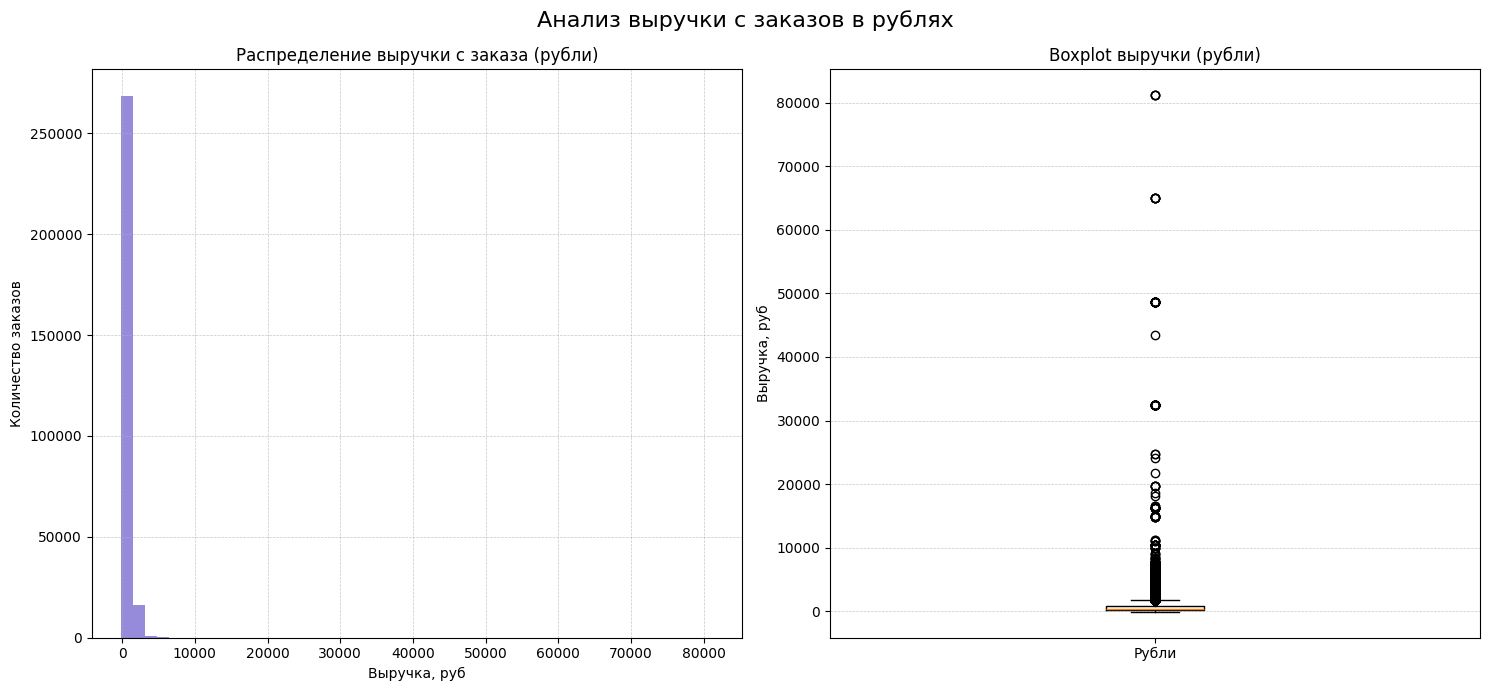

In [19]:
# Данные по рублям
rub_revenue = rub_df['revenue'].copy()

# Создаем фигуру и оси с нужным размером
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 7))

# Строим гистограмму
ax_hist.hist(rub_revenue, bins=50, alpha=0.7, color='slateblue')
ax_hist.set_title('Распределение выручки с заказа (рубли)')
ax_hist.set_xlabel('Выручка, руб')
ax_hist.set_ylabel('Количество заказов')
ax_hist.grid(True, alpha=0.7, linestyle='--', linewidth=0.5)

# Строим boxplot
ax_box.boxplot(rub_revenue)
ax_box.set_title('Boxplot выручки (рубли)')
ax_box.set_ylabel('Выручка, руб')
ax_box.set_xticklabels(['Рубли'])
ax_box.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)

fig.suptitle('Анализ выручки с заказов в рублях', fontsize=16)
plt.tight_layout()
plt.show()

**Промежуточный вывод по анализу распределения выручка с заказа в рублях:**
- Среднее значение (548 руб.) превышает медиану (346 руб.), что указывает на правостороннюю асимметрию распределения.
- Присутствуют отрицательные значения (минимум –90,76 руб.). Вероятно, это возвраты или технические ошибки.

Построим гистограмму распределения значений или диаграмму размаха для визуализации количества билетов в заказе (в рублях).

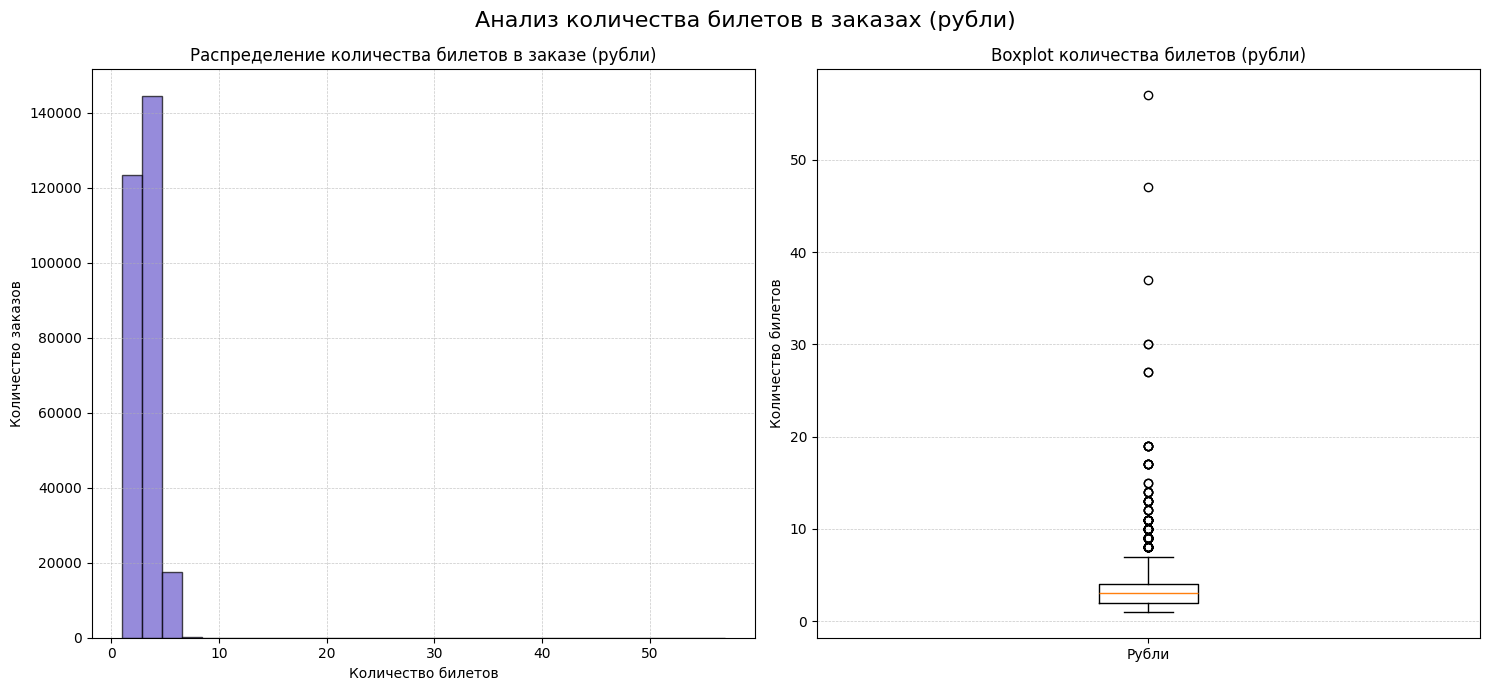

In [20]:
# Данные для рублей
rub_tickets = rub_df['tickets_count'].copy()

# Создаём фигуру с двумя подграфиками
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 7))

# ---- Гистограмма ----
ax_hist.hist(rub_tickets, bins=30, color='slateblue', edgecolor='black', alpha=0.7)
ax_hist.set_title('Распределение количества билетов в заказе (рубли)')
ax_hist.set_xlabel('Количество билетов')
ax_hist.set_ylabel('Количество заказов')
ax_hist.grid(True, alpha=0.7, linestyle='--', linewidth=0.5)

# ---- Boxplot ----
box = ax_box.boxplot(rub_tickets)
ax_box.set_title('Boxplot количества билетов (рубли)')
ax_box.set_ylabel('Количество билетов')
ax_box.set_xticklabels(['Рубли'])
ax_box.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)

# Общий заголовок
fig.suptitle('Анализ количества билетов в заказах (рубли)', fontsize=16)
plt.tight_layout()
plt.show()

**Промежуточный вывод по анализу распределения количества билетов в заказе (в рублях):**
- Большинство заказов содержит от 2 до 4 билетов (медиана 3).

Встречаются заказы с 57 билетами, что может быть аномалией, но специальная обработка этого поля не требуется по условию проекта.

**Визуализация данных для датасета kzt_df.**

Посмотрим столбцы с количественными показателями выручки с заказа и количества билетов на предмет распределения данных и наличия в них выбросов для датасета, содержащего тенге, kzt_df.

In [21]:
# Выводим количественные характеристики столбцов revenпосмотрим распределение выручки для датасета, содержащего рубли, rub_df.ue и tickets_count датасета kzt_df
kzt_df[['revenue', 'tickets_count']].describe()

,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
max,26425.860000,6.000000


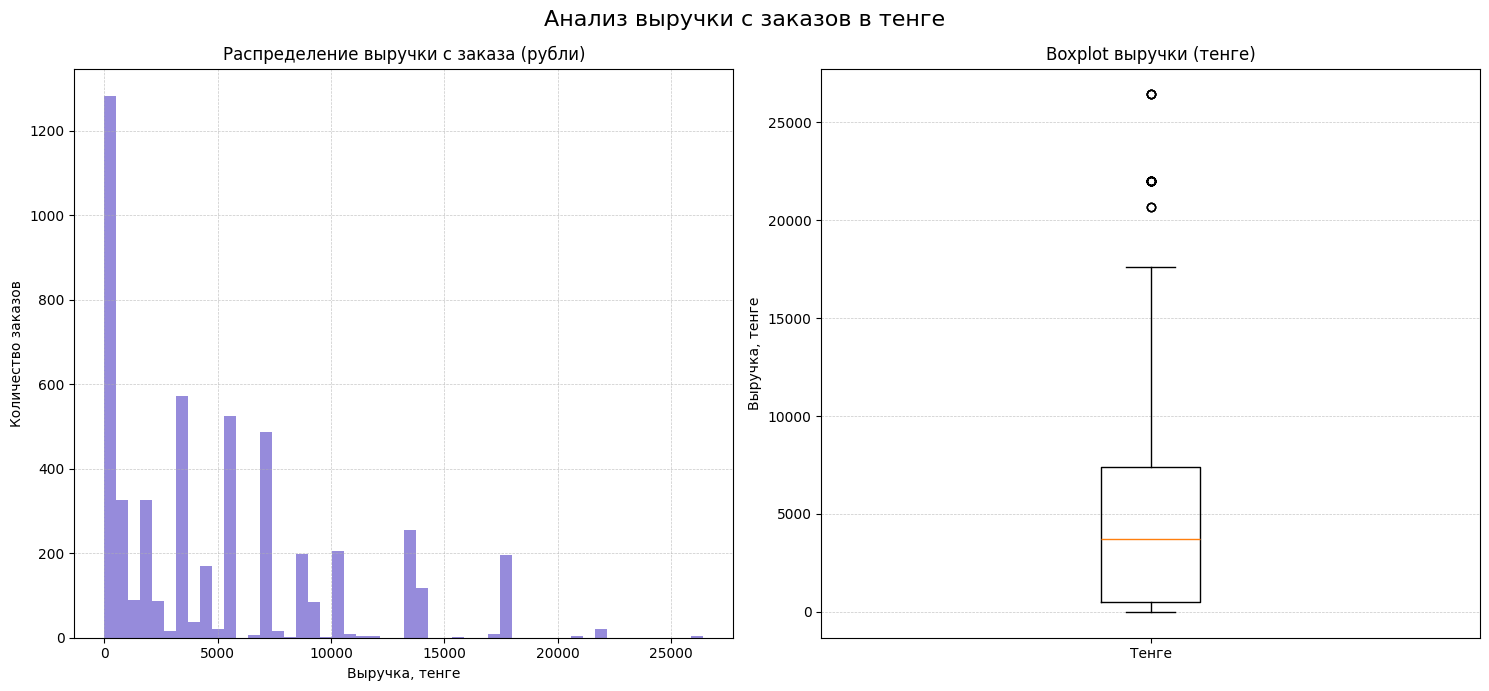

In [22]:
# Данные по тенге
kzt_revenue = kzt_df['revenue'].copy()

# Создаем фигуру и оси с нужным размером
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 7))

# Строим гистограмму
ax_hist.hist(kzt_revenue, bins=50, alpha=0.7, color='slateblue')
ax_hist.set_title('Распределение выручки с заказа (рубли)')
ax_hist.set_xlabel('Выручка, тенге')
ax_hist.set_ylabel('Количество заказов')
ax_hist.grid(True, alpha=0.7, linestyle='--', linewidth=0.5)

# Строим boxplot
ax_box.boxplot(kzt_revenue)
ax_box.set_title('Boxplot выручки (тенге)')
ax_box.set_ylabel('Выручка, тенге')
ax_box.set_xticklabels(['Тенге'])
ax_box.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)

fig.suptitle('Анализ выручки с заказов в тенге', fontsize=16)
plt.tight_layout()
plt.show()

**Промежуточный вывод по анализу распределения выручка с заказа в рублях:**
- Среднее значение (4995 тенге) выше медианы (3698 тенге), что говорит о правосторонней асимметрии распределения.
- Минимальное значение - 0 (отрицательных значений нет, в отличие от рублей).
- Максимальное значение составляет 26 425 тенге при 75-м процентиле 7397 тенге, что указывает на наличие выбросов.

Построим гистограмму распределения значений или диаграмму размаха для визуализации количество билетов в заказе (в тенге).

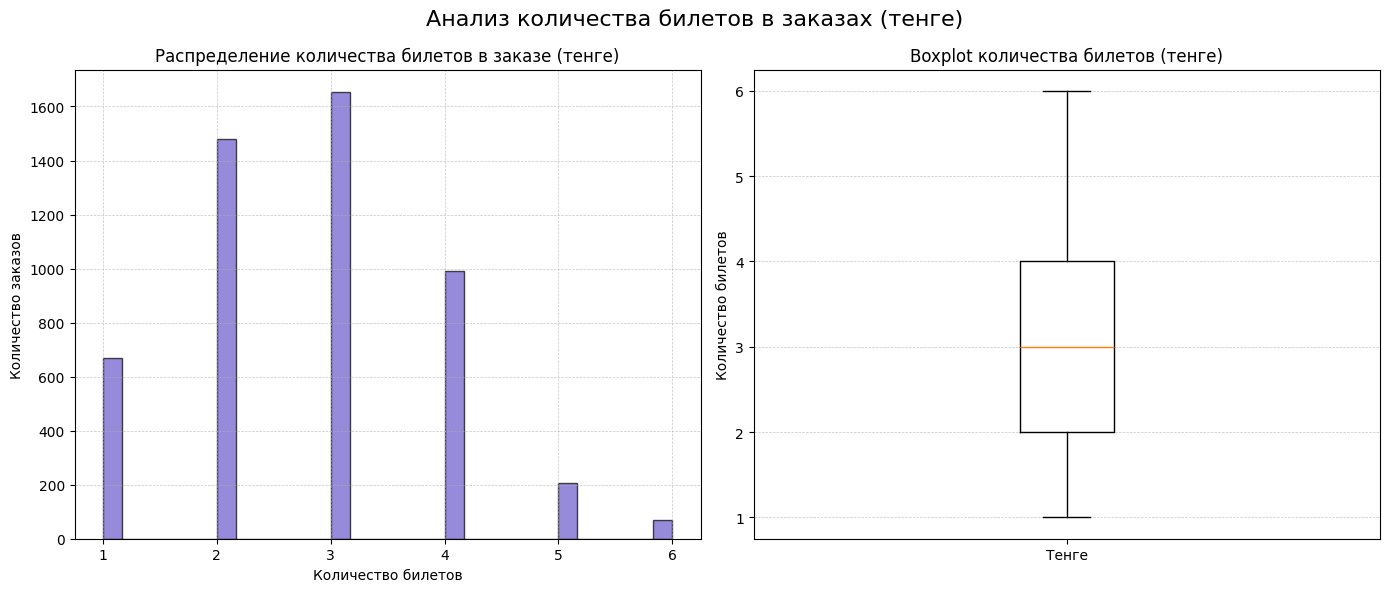

In [23]:
# Данные для рублей
kzt_tickets = kzt_df['tickets_count'].copy()

# Создаём фигуру с двумя подграфиками
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(14, 6))

# ---- Гистограмма ----
ax_hist.hist(kzt_tickets, bins=30, color='slateblue', edgecolor='black', alpha=0.7)
ax_hist.set_title('Распределение количества билетов в заказе (тенге)')
ax_hist.set_xlabel('Количество билетов')
ax_hist.set_ylabel('Количество заказов')
ax_hist.grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

# ---- Boxplot ----
box = ax_box.boxplot(kzt_tickets)
ax_box.set_title('Boxplot количества билетов (тенге)')
ax_box.set_ylabel('Количество билетов')
ax_box.set_xticklabels(['Тенге'])
ax_box.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)

# Общий заголовок
fig.suptitle('Анализ количества билетов в заказах (тенге)', fontsize=16)
plt.tight_layout()
plt.show()

**Промежуточный вывод по анализу распределения количества билетов в заказе (в тенге):**
- Большинство заказов содержит от 2 до 4 билетов (медиана 3 билета, среднее значение - 2,76).
- Максимальное количество билетов - 6, что говорит об отсутствии аномально крупных покупок.

В данных выручки можно наблюдать выбросы как в рублях, так и в тенге. По этой причине, а также чтобы неисказить в дальнейшем анализ отфильтруем эти данные от аномально высокий значений выручки

В начале отберём значения по 99-му процентилю.

In [24]:
# Рассчитываем 99-й процентиль
rub_99 = rub_revenue.quantile(0.99).copy()
kzt_99 = kzt_revenue.quantile(0.99).copy()

print(f'99-й процентиль revenue (рубли): {rub_99:.2f}')
print(f'99-й процентиль revenue (тенге): {kzt_99:.2f}')

99-й процентиль revenue (рубли): 2570.80
99-й процентиль revenue (тенге): 17617.24


Отфильтруем данные.

В начале отфильтруем данные выручки с заказа в рублях.

In [25]:
# Фильтрация для рублей
rub_filtered = rub_df[rub_df['revenue'] <= rub_99].copy()

# Проверим изменения
rub_filtered['revenue'].describe()

count    282742.000000
mean        510.808404
std         500.932220
min         -90.760000
25%         112.120000
50%         340.660000
75%         781.930000
max        2570.800000
Name: revenue, dtype: float64

Теперь отфильтруем данные выручки с заказа в тенге.

In [26]:
# Фильтрация для тенге
kzt_filtered = kzt_df[kzt_df['revenue'] <= kzt_99].copy()

# Проверим изменения
kzt_filtered['revenue'].describe()

count     5040.000000
mean      4893.669063
std       4742.680176
min          0.000000
25%        515.350000
50%       3698.830000
75%       7397.660000
max      17617.240000
Name: revenue, dtype: float64

В результате можно увидеть, что нам удалось отфильтровать выбросы значений выше 99 процентиля.

Объединим отфильтрованные данные в единый датасет.

In [27]:
# Обьединяем данные в единый датасет
tickets_clean = pd.concat([rub_filtered, kzt_filtered], axis=0).reset_index(drop=True)

# Проверяем результат
tickets_clean.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


Посчитаем количественные изменения в данных.

In [28]:
# Считаем количество данных (для рублей), которые отфильтровали из датасета
rub_removed_data = len(rub_df) - len(rub_filtered)

# Считаем процент данных (для рублей), которые отфильтровали из датасета
ratio_rub_removed_data = rub_removed_data / len(rub_df) * 100

print(f'Количество данных (для рублей), которые отфильтровали из датасета rub_df: {rub_removed_data}')
print(f'Процент данных (для рублей), которые отфильтровали из датасета rub_df: {ratio_rub_removed_data}')

Количество данных (для рублей), которые отфильтровали из датасета rub_df: 2800
Процент данных (для рублей), которые отфильтровали из датасета rub_df: 0.9805912965518206


In [29]:
# Считаем количество данных (для тенге), которые отфильтровали из датасета
kzt_removed_data = len(kzt_df) - len(kzt_filtered)

# Считаем процент данных (для тенге), которые отфильтровали из датасета
ratio_kzt_removed_data = kzt_removed_data / len(kzt_df) * 100

print(f'Количество данных (для тенге), которые отфильтровали из датасета kzt_df: {kzt_removed_data}')
print(f'Процент данных (для рублей), которые отфильтровали из датасета kzt_df: {ratio_kzt_removed_data}')

Количество данных (для тенге), которые отфильтровали из датасета kzt_df: 29
Процент данных (для рублей), которые отфильтровали из датасета kzt_df: 0.5721049516669955


In [30]:
# Считаем общее количество данных, которые отфильтровали из датасета
total_removed_data = rub_removed_data + kzt_removed_data

# Считаем количество строк в датасете tickets
total_data = len(tickets)

# Считаем процент данных, которые отфильтровали из датасета
ratio_removed_data = total_removed_data / total_data * 100

print(f'Общее количество данных, которые отфильтровали из датасета tickets: {total_removed_data}')
print(f'Процент данных, которые отфильтровали из датасета tickets: {ratio_removed_data}')

Общее количество данных, которые отфильтровали из датасета tickets: 2829
Процент данных, которые отфильтровали из датасета tickets: 0.9734662486967114


**Промежуточный вывод:**
- **Анализ категориальных признаков** - выполнена проверка уникальных значений. Неявных пропусков не обнаружено.
- **Анализ количественных признаков** - раздельно для заказов в рублях и тенге изучены распределения revenue и tickets_count. Выявлены:
    - Отрицательные значения выручки в рублях (минимум –90,76 руб.), что, вероятно, связано с возвратами или техническими ошибками.
    - Сильные выбросы в обеих валютах, а именно: 81174.54 - максимумальная выручка с заказа в рублях и 26425.86 - максимальная выручка с заказа в тенге, что потребовало фильтрации по 99-му процентилю.
- **Фильтрация выбросов** - для каждой валюты рассчитан 99-й процентиль и оставлены только заказы с доходом, не превышающим 99-й перцентиль:
    - Рубли: 99-й процентиль равен 2570,80 руб. Отсеяно 2800 записей (0.98% от рублёвых заказов).
    - Тенге: 99-й процентиль равен 17 617,24 тенге. Отсеяно 29 записей (0.57% от тенговых заказов).
    - Общее количество данных, которые отфильтровали из датасета tickets: 2829 (0.97% от общего числа данных датасета).
- **Объединение очищенных данных** - выполнено конкатенацией отфильтрованных частей, получен итоговый датасет tickets_clean.

### <a id='part2.3'>2.3. Проверка явных и неявных дубликатов</a>

[Вернуться к содержанию](#content)

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

**Проверка датасета на явные (полные) дубликаты**

In [31]:
# Проверяем явные (полные) дубликаты в датафрейме rest_clean
duplicates_count = tickets_clean.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")

Количество полных дубликатов: 0


In [32]:
# Проверка явных (полных) дубликатов
duplicates = tickets_clean[tickets_clean.duplicated(keep=False)]
print(f"Найдено {len(duplicates)} дублированных строк")
duplicates.head()

Найдено 0 дублированных строк


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address


Таким образом, из результатов проверки датасета на явные (полные) дубликаты видно, что в датасете отсутствуют явные (полные) дубликаты.

**Проверка датасета на неявные дубликаты**

По условию заданию нужно проверить неявные дубликаты по бронированию билета без учёта идентификаторов заказа.

Для поиска неявных дубликатов можно использовать столбец 'created_ts_msk' (дата и время создания заказа (московское время)).

In [33]:
# Создаем массив столбцов
subset_columns = ['user_id', 'event_id', 'created_ts_msk', 
            'tickets_count', 'revenue', 'currency_code', 
            'event_type_description', 'event_type_main']

# Считаем количество дубликатов
duplicate_count = tickets_clean.duplicated(
    subset = subset_columns,
    keep ='first'
)

print(f'Количество неявных дубликатов: {duplicate_count.sum()}')

Количество неявных дубликатов: 43


Записи, в которых есть совпадение по столбцам 'user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue', 'currency_code', 'event_type_description', 'event_type_main', скорее всего, свидетельствуют о наличие технических ошибок (например, задвоение при сборе данных) и об отсутствии полезной информации, а также могут исказить статистику, поэтому их следует удалить.

In [34]:
# Удаляем дубликаты
tickets_clean = tickets_clean.drop_duplicates(
    subset = subset_columns,
    keep = 'first'
).reset_index(drop=True)

# Проверим изменения
duplicate_count = tickets_clean.duplicated(
    subset = subset_columns,
    keep ='first'
)

print(f'Количество неявных дубликатов: {duplicate_count.sum()}')

Количество неявных дубликатов: 0


До предобработки данных, т.е. удаления пропусков, применения фильтров, удаления дубликатов, была создана копия датасета tickets и записана в переменную temp для возможности проверить сделанные изменения после предобработки. Посмотрим на количественные изменения в датасете после вышеуказанной предобработки данных.

In [35]:
# Считаем количество очищенных данных
removed_rows = len(temp) - len(tickets_clean)

# Считаем процент очищенных данных
removed_rows_ratio = removed_rows / len(temp) * 100

# Считаем текущий размер датасета tickets_clean
tickets_clean_size = len(tickets_clean)

print(f'Количество очищенных данных: {removed_rows}')
print(f'Процент очищенных данных: {removed_rows_ratio}')
print(f'Текущий размер датасета tickets_clean: {tickets_clean_size}')

Количество очищенных данных: 2872
Процент очищенных данных: 0.9882626603948234
Текущий размер датасета tickets_clean: 287739


**Промежуточный вывод:**
- **Явные дубликаты.** В датасете tickets_clean отсутствуют явные дубликаты.
- **Неявные дубликаты.** В датасете tickets_clean обнаружено совпадение по следующим столбцам: user_id, event_id, created_ts_msk, tickets_count, revenue, currency_code, event_type_description, event_type_main в количестве 43 записей. Эти записи, вероятно, являются техническими дублями (например, повторная отправка заказа при сбое) и впоследствии были удалены для корректности дальнейшего анализа.
- **Количественная оценка очистки данных:**
    - Исходный размер датасета tickets был записан в переменную temp: 290 849 записей (количество данных после объединения датасетов orders и events, но до предобработки данных: удаления пропусков, фильтрации, удаления дубликатов).
    - Во время предобработки было удалено 238 пропусков, отфильтровано 2829 записей, удалено 43 неявных дубликата записей.
    - После всех шагов очистки размер tickets_clean составил 287 739 записей.
    - В ходе предобработки было отфильтровано и удалено 3 110 записей, что соответствует 1,07% от исходного объёма.

### <a id='part2.4'>2.4. Преобразование типов данных.</a>

[Вернуться к содержанию](#content)

Выведем тип значений у столбцов текущего датасета.

In [36]:
print(tickets_clean.dtypes) # выводим типы данных датасета

order_id                    int64
user_id                    object
created_dt_msk             object
created_ts_msk             object
event_id                    int64
cinema_circuit             object
age_limit                   int64
currency_code              object
device_type_canonical      object
revenue                   float64
service_name               object
tickets_count               int64
total                     float64
days_since_prev           float64
event_name                 object
event_type_description     object
event_type_main            object
organizers                 object
region_name                object
city_name                  object
city_id                     int64
venue_id                    int64
venue_name                 object
venue_address              object
dtype: object


In [37]:
tickets_clean.head() # выводим первые строки датасета tickets_clean

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


#### В текущем датасете можно преобразовать следующие типы данных:
- Столбцы с датой и временем, а именно: created_dt_msk, created_ts_msk имеют текущий тип object, а значит их следует преобразовать в datetime.
- В  столбцах order_id, event_id, age_limit, tickets_count можно понизить разрядность, поскольку диапазон значений позволяет это сделать, а также c целью экономии памяти.
- Столбцы city_id и venue_id имеют текущий тип float64 (возможно из-за наличия строки 'NaN'). После удаления пропусков они не должны содержать NaN, поэтому их можно преобразовать в целочисленный тип данных, при этом понизив их разрядность.
- Cтолбцы с типом данных float, а именно: revenue и total мы не будем трогать, поскольку снизив их разрядность, мы можем исказить данные.
- Столбец days_since_prev следует привести к целочисленному типу Int64.

Преобразуем столбцы с датой и временем в тип данных datetime.

In [38]:
# Преобразование столбцов датасета с датой и временем в datetime
tickets_clean['created_dt_msk'] = pd.to_datetime(tickets_clean['created_dt_msk'])
tickets_clean['created_ts_msk'] = pd.to_datetime(tickets_clean['created_ts_msk'])

Приведём столбцы, содержащие целочисленные значения к типу integer, при этом понизив их разрядность.

In [39]:
# Приводим столбцы с float к integer, при этом понизив разрядность
for column in ['order_id', 'event_id', 'age_limit', 'tickets_count', 'city_id', 'venue_id']:
    tickets_clean[column] = pd.to_numeric(tickets_clean[column], downcast='integer')

Приведём столбец days_since_prev к типу данных Int64.

In [40]:
# Приводим столбецd ays_since_prev к типу данных Int64
tickets_clean['days_since_prev'] = tickets_clean['days_since_prev'].astype('Int64')

In [41]:
# Проверим результат
print(tickets_clean.dtypes)

order_id                           int32
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int32
cinema_circuit                    object
age_limit                           int8
currency_code                     object
device_type_canonical             object
revenue                          float64
service_name                      object
tickets_count                       int8
total                            float64
days_since_prev                    Int64
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int32
venue_id                           int16
venue_name                        object
venue_address                     object
dtype: object


**Промежуточный вывод:**
- Столбцы с датой и временем (created_dt_msk, created_ts_msk) приведены к типу datetime64.
- Столбцы, содержащие целочисленные значения, а именно: order_id, event_id, age_limit, tickets_count, city_id, venue_id приведены к типу данных integer с понижением разрядности:
    -  age_limit и tickets_count стали int8
    -  venue_id приведен к  int16
    -  order_id, event_id, city_id стали int32
- Столбец days_since_prev переведён в специальный тип Int64, который поддерживает пропуски и при этом хранит целые числа.
- Cтолбцы с типом данных float, а именно: revenue и total оставлены без изменения, поскольку снизив их разрядность, данные могут исказиться.

### <a id='part2.5'>2.5. Создание новых столбцов</a>

[Вернуться к содержанию](#content)

**Создадим столбец revenue_rub, в котором приведём выручку с заказа к единой валюте - российскому рублю. Для этой цели используем датасет tenge.**

In [42]:
# Выведем первые строки датасета tenge
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [43]:
# Выводим тип данных датасете tenge
print(tenge.dtypes)

data        object
nominal      int64
curs       float64
cdx         object
dtype: object


В начале преобразуем столбец data, содержащий дату и временя, в тип данных datetime.

In [44]:
# Преобразовываем столбец data в datetime
tenge['data'] = pd.to_datetime(tenge['data'])

# Проверяем результат
print(tenge.dtypes)

data       datetime64[ns]
nominal             int64
curs              float64
cdx                object
dtype: object


Присоединим к датасету tickets_clean датасет tenge, содержащий информацию о курсе тенге к российскому рублю.

In [45]:
# Объединение датасета tickets_clean с датасетом tenge
tickets_clean = tickets_clean.merge(
    tenge[['data', 'curs']], 
    left_on='created_dt_msk', 
    right_on='data', 
    how='left'
)

# Проверим результат
tickets_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287739 entries, 0 to 287738
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287739 non-null  int32         
 1   user_id                 287739 non-null  object        
 2   created_dt_msk          287739 non-null  datetime64[ns]
 3   created_ts_msk          287739 non-null  datetime64[ns]
 4   event_id                287739 non-null  int32         
 5   cinema_circuit          287739 non-null  object        
 6   age_limit               287739 non-null  int8          
 7   currency_code           287739 non-null  object        
 8   device_type_canonical   287739 non-null  object        
 9   revenue                 287739 non-null  float64       
 10  service_name            287739 non-null  object        
 11  tickets_count           287739 non-null  int8          
 12  total                   287739

Создадим столбец revenue_rub.

In [46]:
# Приводим выручку с заказа к единой валюте - российскому рублю
tickets_clean['revenue_rub'] = tickets_clean['revenue'].where(
    tickets_clean['currency_code'] == 'rub',
    tickets_clean['revenue'] * tickets_clean['curs'] / 100
)

**Создадим столбец one_ticket_revenue_rub, в котором рассчитаем выручку с продажи одного билета на мероприятие.**

In [47]:
# Считаем выручку с продажи одного билета на мероприятие.
tickets_clean['one_ticket_revenue_rub'] = tickets_clean['revenue_rub'] / tickets_clean['tickets_count']

**Создадим столбец month, где выделим месяц оформления заказа.**

In [48]:
# Выделяем месяц
tickets_clean['month'] = tickets_clean['created_dt_msk'].dt.month

**Создадим столбец season, который будет содержать информацию о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.**

In [49]:
# Определяем сезон
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

tickets_clean['season'] = tickets_clean['month'].apply(get_season)

# Проверяем результат
tickets_clean.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,data,curs,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,18.6972,1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,18.3419,289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,19.6475,1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,18.5010,8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648,1390.41,463.4700,10,осень


**Промежуточный вывод:**
- В датасет tickets_clean были успешно добавлены четыре новых столбца, необходимые для дальнейшего исследовательского анализа:
    - revenue_rub - выручка с заказа, приведённая к единой валюте - российскому рублю.
    - one_ticket_revenue_rub - выручка с продажи одного билета на мероприятие.
    - month - месяц оформления заказа (целое число от 1 до 12).
    - season - сезон, соответствующий месяцу заказа.

### <a id='conslusion2'>Вывод по проверке ошибок в данных и их предобработке</a>

[Вернуться к содержанию](#content)

**В ходе выполнения этапа предобработки данных были проведены все необходимые операции для приведения данных к виду, необходимому для последующего исследовательского анализа. Ниже перечислены основные действия по предобработке данных и их результаты:**
- **Обработка пропусков в данных:**
    - Столбец days_since_prev содержит 7.54% пропусков (21940 пропусков), что вполне ожидаемо, так как для первого заказа пользователя нет предыдущей покупки. По условию задания пропуски допускаются только в этом столбце, поэтому оставляем его без изменений.
- **Изучение значений в ключевых столбцах:**
    - **Анализ категориальных признаков** - выполнена проверка уникальных значений. Неявных пропусков не обнаружено.
    - **Анализ количественных признаков** - раздельно для заказов в рублях и тенге изучены распределения revenue и tickets_count. Выявлены:
        - Отрицательные значения выручки в рублях (минимум -90,76 руб.), что, вероятно, связано с возвратами или техническими ошибками.
        - Сильные выбросы в обеих валютах, а именно: 81174.54 - максимумальная выручка с заказа в рублях и 26425.86 - максимальная выручка с заказа в тенге, что потребовало фильтрации по 99-му процентилю.
    - **Фильтрация выбросов** - для каждой валюты рассчитан 99-й процентиль и оставлены только заказы с доходом, не превышающим 99-й перцентиль:
        - Рубли: 99-й процентиль равен 2570,80 руб. Отсеяно 2800 записей (0.98% от рублёвых заказов).
        - Тенге: 99-й процентиль равен 17 617,24 тенге. Отсеяно 29 записей (0.57% от тенговых заказов).
        - Общее количество данных, которые отфильтровали из датасета tickets: 2829 (0.97% от общего числа данных датасета).
    - **Объединение очищенных данных** - выполнено конкатенацией отфильтрованных частей, получен итоговый датасет tickets_clean.
- **Проверка явных и неявных дубликатов:**
    - **Явные дубликаты.** В датасете tickets_clean отсутствуют явные дубликаты.
    - **Неявные дубликаты.** В датасете tickets_clean обнаружено совпадение по следующим столбцам: user_id, event_id, created_ts_msk, tickets_count, revenue, currency_code, event_type_description, event_type_main в количестве 43 записей. Эти записи, вероятно, являются техническими дублями (например, повторная отправка заказа при сбое) и впоследствии были удалены для корректности дальнейшего анализа.
    - **Количественная оценка очистки данных:**
        - Исходный размер датасета tickets был записан в переменную temp: 290 849 записей (количество данных после объединения датасетов orders и events, но до предобработки данных: удаления пропусков, фильтрации, удаления дубликатов).
        - Во время предобработки было удалено 238 пропусков, отфильтровано 2829 записей, удалено 43 неявных дубликата записей.
        - После всех шагов очистки размер tickets_clean составил 287 739 записей.
        - В ходе предобработки было отфильтровано и удалено 3 110 записей, что соответствует 1,07% от исходного объёма.
- **Преобразование типов данных:**
    - Столбцы с датой и временем (created_dt_msk, created_ts_msk) приведены к типу datetime64.
    - Столбцы, содержащие целочисленные значения, а именно: order_id, event_id, age_limit, tickets_count, city_id, venue_id приведены к типу данных integer с понижением разрядности:
        -  age_limit и tickets_count стали int8
        -  venue_id приведен к  int16
        -  order_id, event_id, city_id стали int32
    - Столбец days_since_prev переведён в специальный тип Int64, который поддерживает пропуски и при этом хранит целые числа.
    - Cтолбцы с типом данных float, а именно: revenue и total оставлены без изменения, поскольку снизив их разрядность, данные могут исказиться.
- **Создание новых столбцов:**
    - В датасет tickets_clean были успешно добавлены четыре новых столбца, необходимые для дальнейшего исследовательского анализа:
        - revenue_rub - выручка с заказа, приведённая к единой валюте - российскому рублю.
        - one_ticket_revenue_rub - выручка с продажи одного билета на мероприятие.
        - month - месяц оформления заказа (целое число от 1 до 12).
        - season - сезон, соответствующий месяцу заказа.
**Вывод:** Все этапы предобработки выполнены в соответствии с техническим заданием. Данные готовы к исследовательскому анализу.

## <a id='part3'>Часть 3. Исследовательский анализ данных</a>

### <a id='part3.1'>3.1. Анализ распределения заказов по сегментам и их сезонные изменения</a>

[Вернуться к содержанию](#content)

#### Динамика количества заказов по месяцам

Анализ дашборда показал, что в данных наблюдается сезонность - осенью количество заказов увеличивается. На стадии исследовательского анализа изучим изменение пользовательской активности или пользовательского интереса в связи с сезонностью. Проанализируем динамику по таким разрезам:
- тип мероприятия event_type_main;
- тип устройства device_type_canonical;
- категория мероприятий по возрастному рейтингу age_limit.

**Для начала для каждого месяца найдём количество заказов.**

In [50]:
month_orders = tickets_clean.groupby('month', as_index=False).agg(order_count=('order_id', 'count'))
print(month_orders)

   month  order_count
0      6        34164
1      7        40404
2      8        44548
3      9        69350
4     10        99273


Посчитаем процентное изменение количества заказов.

In [51]:
# Первый и последний месяцы
first_month = month_orders.iloc[0]
last_month = month_orders.iloc[-1]

first_count = first_month['order_count']
last_count = last_month['order_count']

# Процентное изменение
change_percent = ((last_count - first_count) / first_count) * 100

print(f"Изменение количества заказов с {first_month['month']} ({first_count}) по {last_month['month']} ({last_count}): {change_percent:.2f}%")

Изменение количества заказов с 6 (34164) по 10 (99273): 190.58%


Для визуализации динамики распределения количества заказов по месяцам построим столбчатую диаграмму.

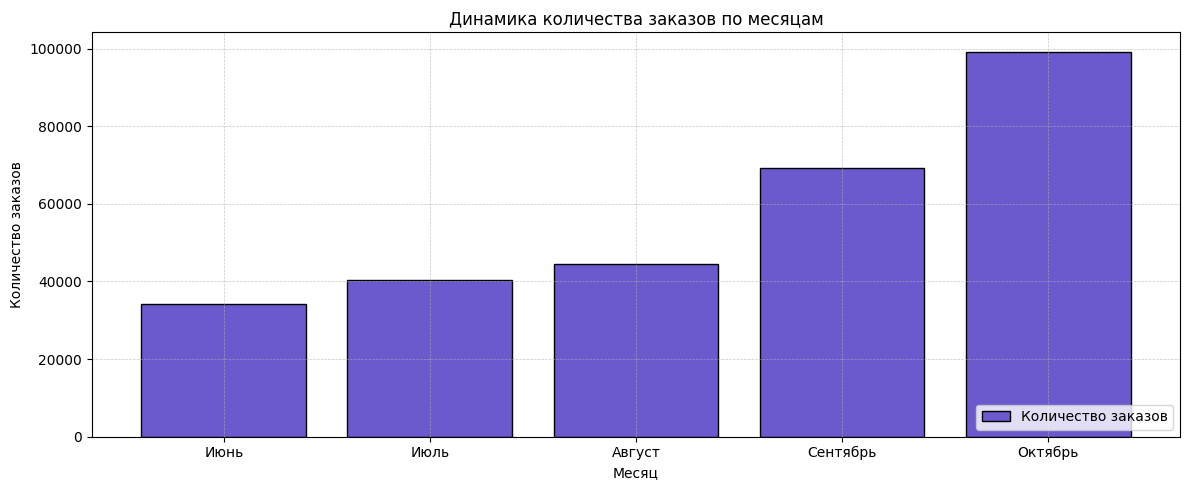

In [52]:
#создаем фигуру и оси с нужным размером
fig, ax = plt.subplots(figsize=(12, 5))

# Строим линейный график для визуализации данных
bars = ax.bar(month_orders['month'], month_orders['order_count'], color='slateblue', edgecolor='black')

# Устанавливаем подписи для заголовка, осей x и y
ax.set_title('Динамика количества заказов по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')

ax.grid(True, alpha=0.7, linestyle='--', linewidth=0.5)

ax.legend(['Количество заказов'], loc='lower right')
ax.set_xticks(month_orders['month'])
ax.set_xticklabels(['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Анализ помесячной динамики заказов показал устойчивый рост пользовательской активности с июня по октябрь 2024 года c 34 164 заказов в июне до 99 273 заказов в октябре.
- Количество заказов с июня по октябрь 2024 года увеличилось на 190,58%. 

#### Распределение заказов по типу мероприятия летом и осенью

**Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям:**
- тип мероприятия,
- тип устройства,
- категория мероприятия по возрастному рейтингу. 

В начале выделим летние и осенние заказы и посчитаем их количество.

In [53]:
# Выделим летние и осенние заказы
summer_data = tickets_clean[tickets_clean['season'] == 'лето'].copy()
autumn_data = tickets_clean[tickets_clean['season'] == 'осень'].copy()

print(f"Летних заказов: {len(summer_data)}")
print(f"Осенних заказов: {len(autumn_data)}")

Летних заказов: 119116
Осенних заказов: 168623


**Посчитаем долю распределения заказов билетов по типу мероприятия в летние и осенние месяцы.**

In [54]:
# Считаем долю распределения заказов билетов по типу мероприятия в летние месяцы
summer_event = (summer_data['event_type_main'].value_counts(normalize=True) * 100).reset_index()
summer_event.columns = ['event_type', 'summer_share']

# Считаем долю распределения заказов билетов по типу мероприятия в осенние месяцы
autumn_event = (autumn_data['event_type_main'].value_counts(normalize=True) * 100).reset_index()
autumn_event.columns = ['event_type', 'autumn_share']

# Объединяем данные
season_events = pd.merge(summer_event, autumn_event, on='event_type', how='outer').copy()

# Сортируем по убыванию летней доли заказов
season_events = season_events.sort_values('summer_share', ascending=False).reset_index(drop=True)

print('\nПроцент распределения заказов билетов по типу мероприятия в летние и осенние месяцы:')
print(season_events)


Процент распределения заказов билетов по типу мероприятия в летние и осенние месяцы:
  event_type  summer_share  autumn_share
0   концерты     42.618960     37.204889
1     другое     27.171832     19.703718
2      театр     20.100574     25.342332
3    стендап      5.327580      4.105608
4      спорт      2.523590     11.195982
5   выставки      2.028275      1.444643
6       ёлки      0.229188      1.002829


Визуализируем процент распределения заказов билетов по типу мероприятия в летние и осенние месяцы.

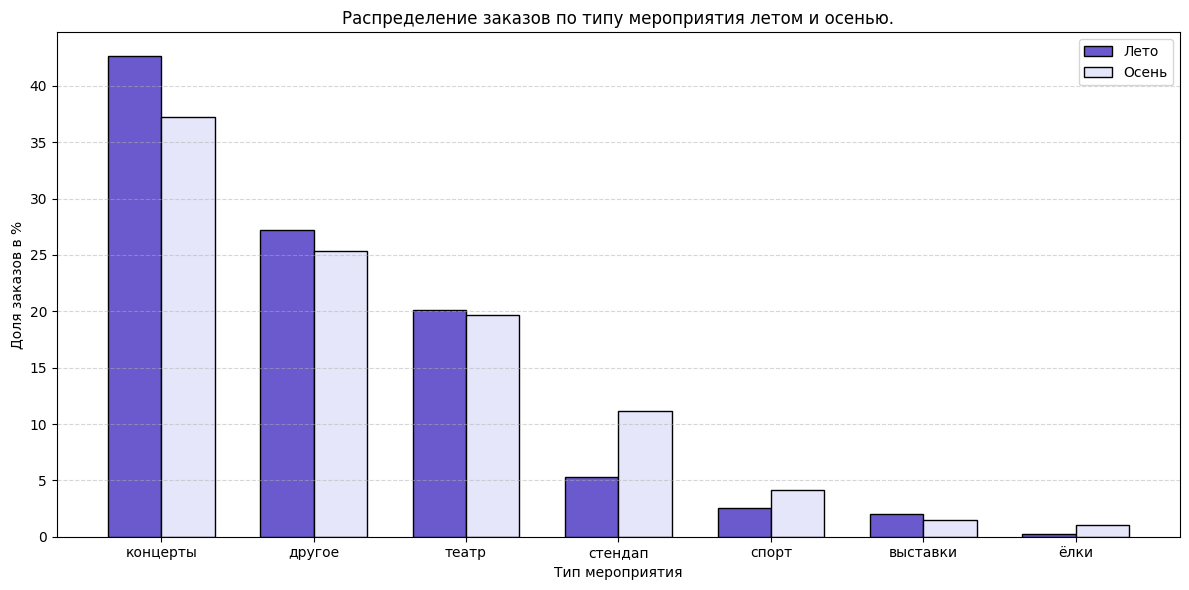

In [55]:
# Создаём фигуру и оси
fig, ax = plt.subplots(figsize=(12, 6))

# Задаём позиции для категорий
x = range(len(season_events.index))
width = 0.35 # Ширина одно столбца

# Строим столбчатую диаграмму
ax.bar([i - width/2 for i in x], summer_event['summer_share'], width, label='Лето', color='slateblue', edgecolor='black')
ax.bar([i + width/2 for i in x], autumn_event['autumn_share'], width, label='Осень', color='lavender', edgecolor='black')

# Устанавливаем названия
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Доля заказов в %')
ax.set_title('Распределение заказов по типу мероприятия летом и осенью.')
ax.set_xticks(x)
ax.set_xticklabels(season_events['event_type'], rotation=0)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Концерты - лидируют в обоих сезонах, но их доля снижается с 42.61% летом до 37.2% осенью.
- Театр - доля растёт с 20.1% до 25.34%, что указывает на начало театрального сезона и повышенный интерес осенью.
- Спорт - доля увеличивается с 2,52% до 11,19%, что может быть связано с возобновлением спортивных событий после летнего перерыва.
- Другое - доля снижается с 27,17% до 19,7%, возможно, из-за перераспределения интересов в сторону более специализированных мероприятий.
- Стендап демонстрируют незначительное снижение доли с 5.32% до 4.1%.
- Выставки также демонстрируют незначительное снижение доли с 2.02% до 1.44%.
- Ёлки, наоборот, увеличивают свою долю осенью с 0.2% до 1%.

#### Распределение заказов по типу устройства летом и осенью

**Посчитаем долю распределения заказов билетов по типу устройства в летние и осенние месяцы.**

In [56]:
# Считаем долю распределения заказов билетов по типу устройства в летние месяцы
summer_device = summer_data['device_type_canonical'].value_counts(normalize=True) * 100

# Считаем долю распределения заказов билетов по типу устройства в осенние месяцы
autumn_device = autumn_data['device_type_canonical'].value_counts(normalize=True) * 100

# Создание датафрейма из summer_device и autumn_device
device_comparison = pd.DataFrame({'summer_share': summer_device, 'autumn_share': autumn_device}).copy()

# Выводим первые строки получившегося датасета
device_comparison.head()

,summer_share,autumn_share
device_type_canonical,,
mobile,80.642399,79.656986
desktop,19.357601,20.343014


Визуализируем процент распределения заказов билетов по типу устройства в летние и осенние месяцы.

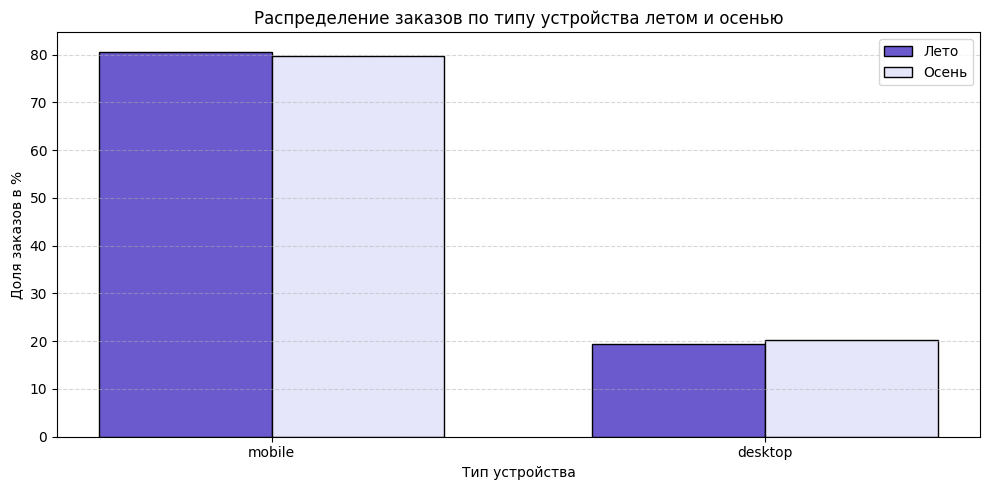

In [57]:
# Строим столбчатую диаграмму
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(device_comparison.index))
width = 0.35

# Строим столбчатую диаграмму
ax.bar([i - width/2 for i in x], device_comparison['summer_share'], width, label='Лето', color='slateblue', edgecolor='black')
ax.bar([i + width/2 for i in x], device_comparison['autumn_share'], width, label='Осень', color='lavender', edgecolor='black')

# Устанавливаем названия
ax.set_xlabel('Тип устройства')
ax.set_ylabel('Доля заказов в %')
ax.set_title('Распределение заказов по типу устройства летом и осенью')
ax.set_xticks(x)
ax.set_xticklabels(device_comparison.index, rotation=0)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Мобильные устройства доминируют в обоих сезонах: летом через мобильные устройства было совершено 80.64% заказов билетов, осенью – 79.65%. Небольшое снижение на 0.9 процентного пункта может быть связано с ростом использования десктопов.
- Заказы билетов через десктопы составляют около 19.35% летом и 20.34% осенью, что говорит о незначительном увеличении доли на 0,9 процентных пункта.

#### Распределение заказов по возрастному рейтингу летом и осенью

**Посчитаем долю распределения заказов билетов по возрастному рейтингу в летние и осенние месяцы.**

In [58]:
# Cчитаем долю распределения заказов билетов по возрастному рейтингу для лета
summer_age = (summer_data['age_limit'].value_counts(normalize=True) * 100).reset_index()
summer_age.columns = ['age_limit', 'summer_share']

# Cчитаем долю распределения заказов билетов по возрастному рейтингу для осени
autumn_age = (autumn_data['age_limit'].value_counts(normalize=True) * 100).reset_index()
autumn_age.columns = ['age_limit', 'autumn_share']

# Объединяем данные из summer_age и autumn_age
age_comparison = pd.merge(summer_age, autumn_age, on='age_limit', how='outer')
age_comparison = age_comparison.sort_values('age_limit').reset_index(drop=True).copy()

print(age_comparison)

   age_limit  summer_share  autumn_share
0          0     17.967360     23.618368
1          6     18.194869     17.624523
2         12     20.537963     22.097816
3         16     28.337923     26.220622
4         18     14.961886     10.438671


Визуализируем процент распределения заказов билетов по возрастному рейтингу в летние и осенние месяцы.

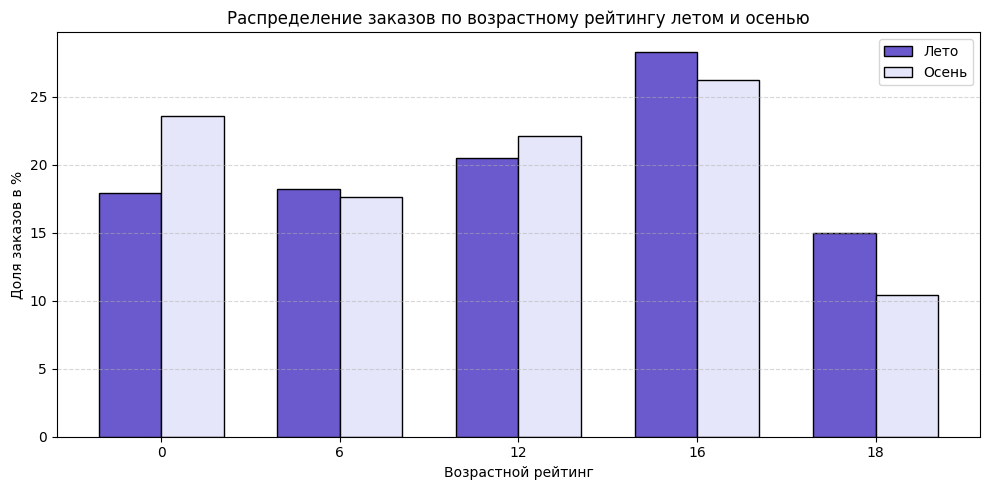

In [59]:
# Создаём фигуру и оси
fig, ax = plt.subplots(figsize=(10, 5))

# Задаём позиции для категорий
x = range(len(age_comparison))
width = 0.35

# Строим столбчатую диаграмму
ax.bar([i - width/2 for i in x], age_comparison['summer_share'], width, label='Лето', color='slateblue', edgecolor='black')
ax.bar([i + width/2 for i in x], age_comparison['autumn_share'], width, label='Осень', color='lavender', edgecolor='black')

# Устанавливаем названия
ax.set_xlabel('Возрастной рейтинг')
ax.set_ylabel('Доля заказов в %')
ax.set_title('Распределение заказов по возрастному рейтингу летом и осенью')
ax.set_xticks(x)
ax.set_xticklabels(age_comparison['age_limit'])
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Для мероприятий без возрастных ограничений (0+) доля заказов билетов выросла с 17,96% летом до 23,61% осенью. Это может быть связано с увеличением количества семейных и детских мероприятий в осенний период.
- Для мероприятий с возрастным ограничением 6+ доля заказов билетов незначительно снизилась с 18,19% летом до 17,62% осенью.
- Для мероприятий с возрастным ограничением 12+ доля заказов билетов выросла с 20,53% летом до 22,09% осенью.
- Для мероприятий с возрастным ограничением 16+ доля заказов билетов снизилась с 28,33% летом до 26,22% осенью.
- Для мероприятий с возрастным ограничением 18+ доля заказов билетов снизилась наиболее существенно: с 14,96% до 10,43%.

Таким образом, осенью наблюдается перераспределение спроса в сторону мероприятий с низкими возрастными ограничениями, тогда как доля мероприятий с возрастным ограничением (16+, 18+) сокращается. Это может отражать изменение состава афиши: в осенние месяцы увеличивается количество семейных и школьных мероприятий, а также событий для подростков, в то время как доля мероприятий для взрослых (16+, 18+) снижается.

#### Средняя выручка с заказа одного билета в зависимости от типа мероприятия летом и осенью

**Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.**

Выведем среднюю выручку с продажи одного билета в зависимости от типа мероприятия за лето.

In [60]:
# Средняя выручка с продажи одного билета на мероприятия летом
summer_revenue_per_ticket = summer_data.groupby('event_type_main')['one_ticket_revenue_rub'].mean().reset_index()
summer_revenue_per_ticket.columns = ['event_type', 'summer_mean']

print(summer_revenue_per_ticket)

  event_type  summer_mean
0   выставки    86.416198
1     другое    77.439799
2   концерты   304.785459
3      спорт    50.761831
4    стендап   218.518107
5      театр   214.138855
6       ёлки   271.436176


Выведем среднюю выручку с продажи одного билета в зависимости от типа мероприятия за осень.

In [61]:
# Средняя выручка на билет осенью
autumn_revenue_per_ticket = autumn_data.groupby('event_type_main')['one_ticket_revenue_rub'].mean().reset_index()
autumn_revenue_per_ticket.columns = ['event_type', 'autumn_mean']

print(autumn_revenue_per_ticket)

  event_type  autumn_mean
0   выставки    90.603610
1     другое    76.115334
2   концерты   268.360658
3      спорт    49.970896
4    стендап   231.124973
5      театр   175.977088
6       ёлки   229.585589


Объединим полученные раннее датасеты summer_revenue_per_ticket и autumn_revenue_per_ticket.

In [62]:
# Объединяем датасеты summer_revenue_per_ticket и autumn_revenue_per_ticket
revenue_per_ticket_comparison = pd.merge(summer_revenue_per_ticket, autumn_revenue_per_ticket, on='event_type', how='outer')

# Проверяем результат
print(revenue_per_ticket_comparison)

  event_type  summer_mean  autumn_mean
0   выставки    86.416198    90.603610
1     другое    77.439799    76.115334
2   концерты   304.785459   268.360658
3      спорт    50.761831    49.970896
4    стендап   218.518107   231.124973
5      театр   214.138855   175.977088
6       ёлки   271.436176   229.585589


Визуализируем среднюю выручку с продажи одного билета в зависимости от типа мероприятия за летом и осень.

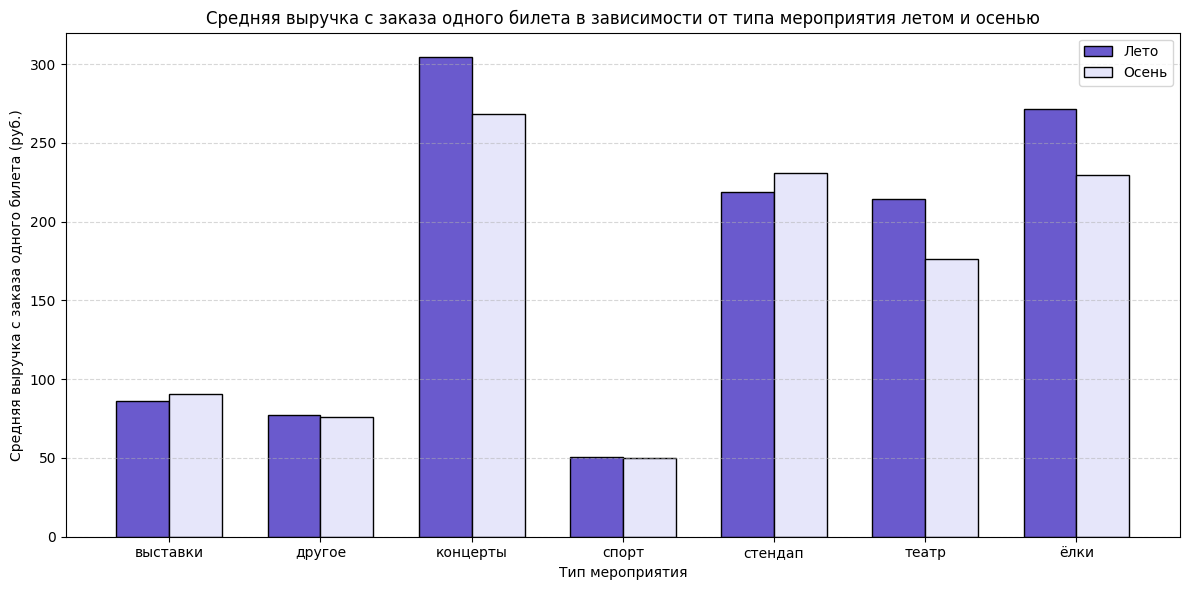

In [63]:
# Создаём фигуру и оси
fig, ax = plt.subplots(figsize=(12, 6))

# Задаём позиции для категорий
x = range(len(revenue_per_ticket_comparison))
width = 0.35

# Строим столбчатую диаграмму
ax.bar([i - width/2 for i in x], revenue_per_ticket_comparison['summer_mean'], width, label='Лето', color='slateblue', edgecolor='black')
ax.bar([i + width/2 for i in x], revenue_per_ticket_comparison['autumn_mean'], width, label='Осень', color='lavender', edgecolor='black')

# Устанавливаем названия
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Средняя выручка с заказа одного билета (руб.)')
ax.set_title('Средняя выручка с заказа одного билета в зависимости от типа мероприятия летом и осенью')
ax.set_xticks(x)
ax.set_xticklabels(revenue_per_ticket_comparison['event_type'], rotation=0)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Найдём относительное изменение осенних значений средней выручки с одного билета по сравнению с летними.

In [64]:
# Рассчитываем относительное изменение 
revenue_per_ticket_comparison['change_percent'] = ((revenue_per_ticket_comparison['autumn_mean'] - 
                                                    revenue_per_ticket_comparison['summer_mean']) / 
                                                   revenue_per_ticket_comparison['summer_mean'] * 100).round(1)

# Сортируем полученный результат
revenue_per_ticket_comparison = revenue_per_ticket_comparison.sort_values('summer_mean', ascending=False).reset_index(drop=True)

print('Средняя выручка с заказа билета по типам мероприятий:')
print(revenue_per_ticket_comparison)

Средняя выручка с заказа билета по типам мероприятий:
  event_type  summer_mean  autumn_mean  change_percent
0   концерты   304.785459   268.360658           -12.0
1       ёлки   271.436176   229.585589           -15.4
2    стендап   218.518107   231.124973             5.8
3      театр   214.138855   175.977088           -17.8
4   выставки    86.416198    90.603610             4.8
5     другое    77.439799    76.115334            -1.7
6      спорт    50.761831    49.970896            -1.6


Создадим визуализацию для относительных изменений осенних значений средней выручки с одного билета по сравнению с летними.

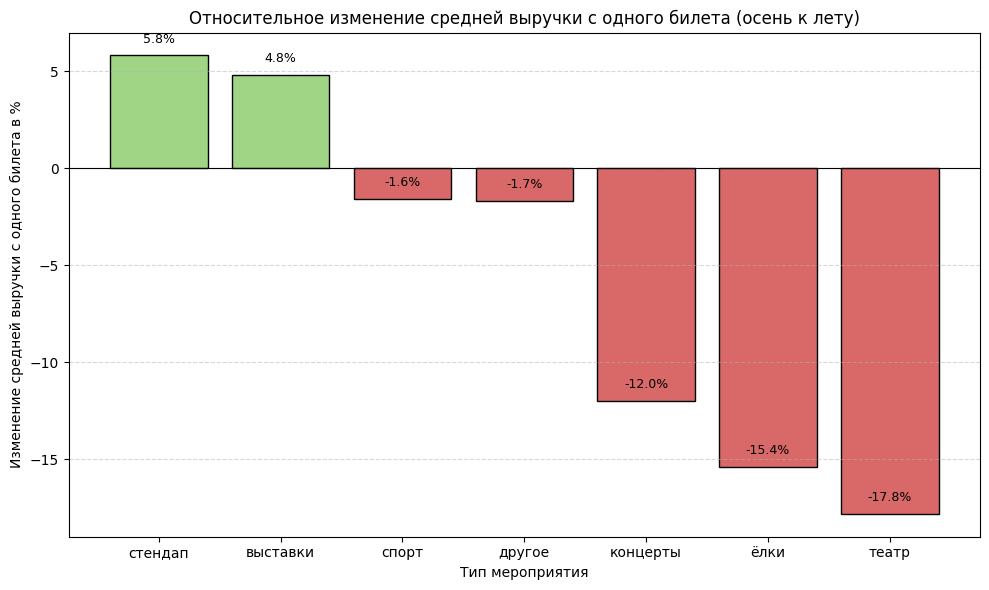

In [65]:
# Сортируем по убыванию относительное изменение осенних значений по сравнению с летними
revenue_per_ticket_comparison = revenue_per_ticket_comparison.sort_values('change_percent', ascending=False).reset_index(drop=True)

# Пишем условие для цвета
colors = ['#A0D585' if x >= 0 else '#D96868' for x in revenue_per_ticket_comparison['change_percent']]

# Создаём фигуру и оси
fig, ax = plt.subplots(figsize=(10, 6))

# Строим столбчатую диаграмму
bars = ax.bar(
    revenue_per_ticket_comparison['event_type'], 
    revenue_per_ticket_comparison['change_percent'], 
    color=colors,
    edgecolor='black'
)

# Добавляем текст к каждому столбцу
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Изменение средней выручки с одного билета в %')
ax.set_title('Относительное изменение средней выручки с одного билета (осень к лету)')

# Устанавливаем позиции и метки
ax.set_xticks(range(len(revenue_per_ticket_comparison)))
ax.set_xticklabels(revenue_per_ticket_comparison['event_type'], rotation=0)

ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Промежуточный вывод о распределении заказов в каждой категории с наступлением осени:**
- **Концерты** - лидируют по средней цене за билет как летом (304.78 руб.), так и осенью (268.36 руб.), однако наблюдается снижение стоимости на билет на –12%.
- **Ёлки** - летом средняя цена составляла 271.43 руб., осенью снизилась до 229.58 руб., падение на –15.4%.
- **Стендап** - осенью средняя цена выросла: с 218.51 руб. до 231.12 руб., рост цены на +5.8%.
- **Театр** - наиболее значительное снижение средней стоимости билета осенью: с 214.13 руб. до 175.97 руб., падение стоимости билета на -17,8%.
- **Выставки** - небольшой рост средней стоимости билета осенью: с 86.41 руб. до 90.60 руб., рост на +4.8%.
- **Другое** - незначительное снижение средней стоимости билета осенью: с 77.43 руб. до 76.11 руб., падение на –1.7%.
- **спорт** - незначительное снижение средней стоимости билета осенью: с 50.76 руб. до 49.97 руб., падение на –1.6%.

### <a id='part3.2'>3.2. Осенняя активность пользователей</a>

[Вернуться к содержанию](#content)

#### Динамика изменений осенней активности пользователей по дням

Изучим активность пользователей осенью 2024 года. В вашем распоряжении данные за два осенних месяца. 

В начале проанализируем динамику изменений осенней активности пользователей по дням:
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

In [66]:
# Группируем по дате и считаем основные числовые показатели
daily_stats = autumn_data.groupby('created_dt_msk').agg(
    orders_count=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Рассчитываем среднее число заказов на пользователя
daily_stats['avg_orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']

# Выводим полученные результаты
daily_stats.head()

,created_dt_msk,orders_count,dau,avg_ticket_price,avg_orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464639,2.404181
2,2024-09-03,5113,778,80.350151,6.571979
3,2024-09-04,1773,686,178.048069,2.584548
4,2024-09-05,1944,739,189.510156,2.630582


Создадим визуализацию для того, чтобы проследить динамику изменений осенней активности пользователей по дням.

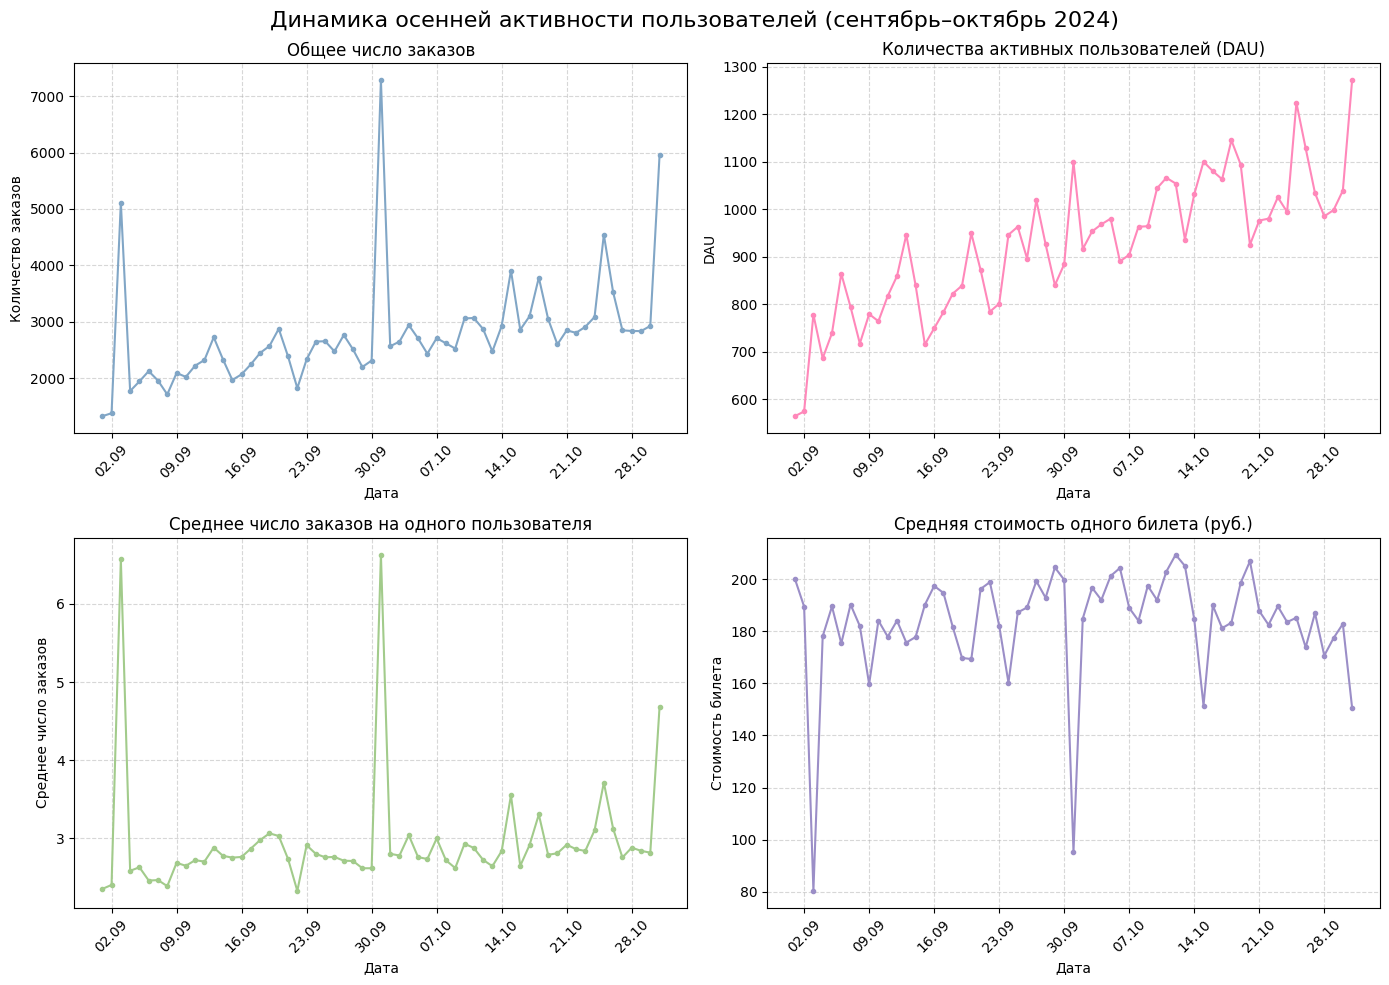

In [67]:
# Создаём фигуру и оси
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Динамика осенней активности пользователей (сентябрь–октябрь 2024)', fontsize=16)

# Создаём линейный график для общего числа заказов
ax[0,0].plot(daily_stats['created_dt_msk'], daily_stats['orders_count'], 
               color='#81A6C6', marker='o', markersize=3)
ax[0,0].set_title('Общее число заказов')
ax[0,0].set_ylabel('Количество заказов')
ax[0,0].grid(True, linestyle='--', alpha=0.5)

# # Создаём линейный график для DAU
ax[0,1].plot(daily_stats['created_dt_msk'], daily_stats['dau'], 
               color='#FF88BA', marker='o', markersize=3)
ax[0,1].set_title('Количества активных пользователей (DAU)')
ax[0,1].set_ylabel('DAU')
ax[0,1].grid(True, linestyle='--', alpha=0.5)

# # Создаём линейный график для среднего числа заказов на одного пользователя
ax[1,0].plot(daily_stats['created_dt_msk'], daily_stats['avg_orders_per_user'], 
               color='#A2CB8B', marker='o', markersize=3)
ax[1,0].set_title('Среднее число заказов на одного пользователя')
ax[1,0].set_ylabel('Среднее число заказов')
ax[1,0].grid(True, linestyle='--', alpha=0.5)

# # Создаём линейный график для средней стоимости одного билета
ax[1,1].plot(daily_stats['created_dt_msk'], daily_stats['avg_ticket_price'], 
               color='#9B8EC7', marker='o', markersize=3)
ax[1,1].set_title('Средняя стоимость одного билета (руб.)')
ax[1,1].set_ylabel('Стоимость билета')
ax[1,1].grid(True, linestyle='--', alpha=0.5)

# Настройка оси x для всех подграфиков
for ax in ax.flat:
    ax.set_xlabel('Дата')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    
    # Поворот подписей
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# Увеличиваем расстояние между подграфиками
plt.subplots_adjust(hspace=0.3)

plt.tight_layout()
plt.show()

#### Динамика недельной цикличности осенней активности пользователей по дням

**Изучим недельную цикличность.**

В начале создадим столбцы с номерами дней недели, названиями дней недели и типом дней недели (будни, выходные).

In [68]:
# Создаем столбец с номером дня недели
daily_stats['day_of_week'] = daily_stats['created_dt_msk'].dt.weekday

# Добавляем столбец с названием дня недели
weekday_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
daily_stats['weekday_names'] = daily_stats['day_of_week'].map(weekday_names)

# Добавляем столбец тип дня
daily_stats['type_of_day'] = daily_stats['day_of_week'].apply(lambda x: 'выходной' if x >= 5 else 'будни')

# Проверим результат
daily_stats.head()

,created_dt_msk,orders_count,dau,avg_ticket_price,avg_orders_per_user,day_of_week,weekday_names,type_of_day
0,2024-09-01,1327,564,200.168708,2.352837,6,Вс,выходной
1,2024-09-02,1380,574,189.464639,2.404181,0,Пн,будни
2,2024-09-03,5113,778,80.350151,6.571979,1,Вт,будни
3,2024-09-04,1773,686,178.048069,2.584548,2,Ср,будни
4,2024-09-05,1944,739,189.510156,2.630582,3,Чт,будни


Сгруппируем данные по дням недели для подсчёта основных числовых показателей.

In [69]:
# Считаем статистику по дням недели
weekday_stats = daily_stats.groupby('day_of_week').agg(
    weekday_name=('weekday_names', 'first'),
    avg_orders=('orders_count', 'mean'),
    avg_dau=('dau', 'mean')
).round(2).reset_index(drop=True)

# Выводим результат
print('\nСтатистика осенней активности пользователей по дням недели:\n')
print(weekday_stats)


Статистика осенней активности пользователей по дням недели:

  weekday_name  avg_orders  avg_dau
0           Пн     2390.33   853.67
1           Вт     3498.56   934.56
2           Ср     2543.44   923.56
3           Чт     3018.33   962.11
4           Пт     3104.38  1022.62
5           Сб     2667.62   961.00
6           Вс     2154.56   822.78


Создадим столбчатую диаграмму для визуализации осенней активности пользователей по заказу билетов по дням недели

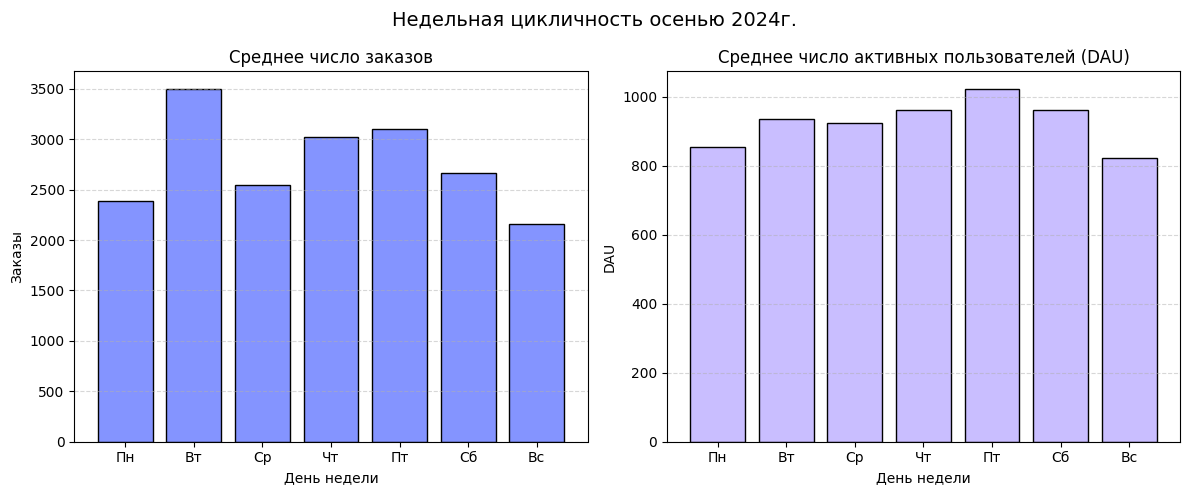

In [70]:
# Создаём фигуру и оси
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Недельная цикличность осенью 2024г.', fontsize=14)

# Создаём столбчатую диаграмму для среднего числа заказов
ax[0].bar(weekday_stats['weekday_name'], weekday_stats['avg_orders'], color='#8494FF', edgecolor='black')
ax[0].set_title('Среднее число заказов')
ax[0].set_ylabel('Заказы')
ax[0].grid(True, axis='y', linestyle='--', alpha=0.5)
ax[0].set_xlabel('День недели')

# Создаём столбчатую диаграмму для среднего числа активных пользователей (DAU)
ax[1].bar(weekday_stats['weekday_name'], weekday_stats['avg_dau'], color='#C9BEFF', edgecolor='black')
ax[1].set_title('Среднее число активных пользователей (DAU)')
ax[1].set_ylabel('DAU')
ax[1].grid(True, axis='y', linestyle='--', alpha=0.5)
ax[1].set_xlabel('День недели')

plt.tight_layout()
plt.show()

Сгруппируем данные по типу дня недели (будни/выходной) для подсчёта основных числовых показателей.

In [71]:
# Считаем статистику по типу дня недели (будни/выходные)
type_of_day_stats = daily_stats.groupby('type_of_day').agg(
    type_of_day=('type_of_day', 'first'),
    avg_orders=('orders_count', 'mean'),
    avg_dau=('dau', 'mean')
).round(2).reset_index(drop=True)

print('\nСтатистика осенней активности пользователей по будням и выходным:\n')
print(type_of_day_stats)


Статистика осенней активности пользователей по будням и выходным:

  type_of_day  avg_orders  avg_dau
0       будни     2906.61   937.41
1    выходной     2396.00   887.82


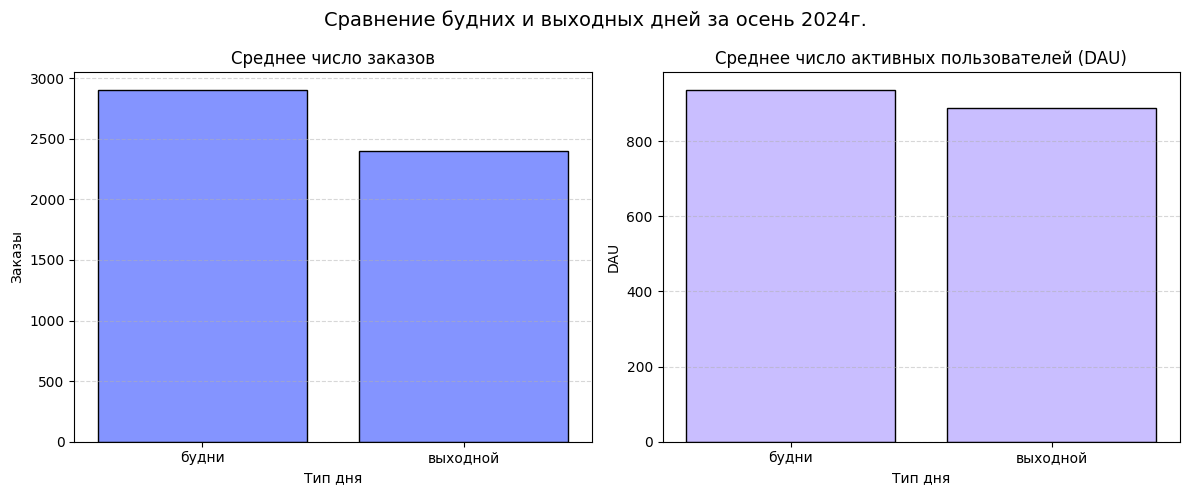

In [72]:
# Создаём фигуру и оси
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Сравнение будних и выходных дней за осень 2024г.', fontsize=14)

# Столбчатая диаграмма для среднего числа заказов
ax[0].bar(type_of_day_stats['type_of_day'], type_of_day_stats['avg_orders'], color='#8494FF', edgecolor='black')
ax[0].set_title('Среднее число заказов')
ax[0].set_ylabel('Заказы')
ax[0].grid(True, axis='y', linestyle='--', alpha=0.5)
ax[0].set_xlabel('Тип дня')

# Столбчатая диаграмма для среднего числа активных пользователей (DAU)
ax[1].bar(type_of_day_stats['type_of_day'], type_of_day_stats['avg_dau'], color='#C9BEFF', edgecolor='black')
ax[1].set_title('Среднее число активных пользователей (DAU)')
ax[1].set_ylabel('DAU')
ax[1].grid(True, axis='y', linestyle='--', alpha=0.5)
ax[1].set_xlabel('Тип дня')

plt.tight_layout()
plt.show()

**Промежуточный вывод по осенней активности пользователей за период с сентября по октябрь 2024г.:**
- **Общая динамика:**
    - Количество заказов и DAU имеет тенденцию к росту от сентября к октябрю. В сентябре среднедневное число заказов составило в районе 2 300, в октябре уже около 3 100. Пиковые значения приходятся на конец октября (например, 25 октября - 4 545 заказов, 1 224 DAU).
    - 3 сентября и 1 октября наблюдаются резкие скачки показателей:
        - 3 сентября: 5 113 заказов, DAU 778, средняя цена билета упала до 80 руб. (возможно, связано с осенними акциями).
        - 1 октября: 7 287 заказов, DAU 1 099, средняя цена билета также снизилась до 95 руб.
- **Среднее число заказов на пользователя:**
    - В обычные дни этот показатель имеет диапазон от 2,5 до 3,0, что означает, что в среднем пользователь совершает 2–3 заказа в день.
    - В дни пиковых продаж (3 сентября, 1 октября) значение достигает 6,5–6,6, что говорит о кратковременном всплеске массовых покупок.
- **Средняя стоимость билета:**
    - В основном стоимость билета стабильна и не имеет ярко выраженного тренда, в среднем диапазон стоимости билета составляет от 170 руб. до 210 руб.
    - Заметное снижение цены наблюдается 3 сентября и 1 октября (до 80–95 руб.).
- **Недельная цикличность:**
    - **Анализ по дням недели:**
        - Максимальное количество заказов и DAU в среднем приходится на вторник (3 499 заказов, 935 DAU) и пятницу (3 104 заказа, 1 023 DAU).
        - Минимумы  количество заказов и DAU в среднем приходится на воскресенье (2 155 заказов, 823 DAU) и понедельник (2 390 заказов, 854 DAU).
        - Среда и четверг показывают средние значения.
    - **Сравнение пользовательской активности в будни и выходные:**
        - В будни (пн–пт) в среднем больше заказов в сравнении с выходными (сб–вс) - 2 907 заказов в будни против 2 396 заказа в выходные.
        - В будни (пн–пт) также в среднем выше DAU в сравнении с выходные (сб–вс) - 937 DAU в будни против 888 DAU в выходные.

### <a id='part3.3'>3.3. Популярные события и партнёры</a>

[Вернуться к содержанию](#content)

#### Популярные события

Выгрузим основную информацию датасета tickets_clean.

In [73]:
# Для удобства выводим информацию датасета tickets_clean
tickets_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287739 entries, 0 to 287738
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287739 non-null  int32         
 1   user_id                 287739 non-null  object        
 2   created_dt_msk          287739 non-null  datetime64[ns]
 3   created_ts_msk          287739 non-null  datetime64[ns]
 4   event_id                287739 non-null  int32         
 5   cinema_circuit          287739 non-null  object        
 6   age_limit               287739 non-null  int8          
 7   currency_code           287739 non-null  object        
 8   device_type_canonical   287739 non-null  object        
 9   revenue                 287739 non-null  float64       
 10  service_name            287739 non-null  object        
 11  tickets_count           287739 non-null  int8          
 12  total                   287739

Посчитаем для каждого региона уникальное количество мероприятий и общее число заказов. 

In [74]:
# Считаем статистику для регионов
region_stats = tickets_clean.groupby('region_name').agg(
    events_count=('event_id', 'nunique'),
    orders_count=('order_id', 'count')
).reset_index().copy()

Посчитаем доли проводимых мероприятий от их общего числа, а также доли заказов в регионе от общего числа заказов в зависимости от региона.

In [75]:
# Считаем общее количество событий и заказов
total_events = tickets_clean['event_id'].nunique()
total_orders = len(tickets_clean)

# Считаем доли
region_stats['events_share'] = (region_stats['events_count'] / total_events * 100).round(2)
region_stats['orders_share'] = (region_stats['orders_count'] / total_orders * 100).round(2)

Отсортируем полученные результаты.

In [76]:
# Сортируем по количеству мероприятий (для топ‑5)
top5_region_events = region_stats.sort_values('events_count', ascending=False).reset_index(drop=True).head(5)

# Сортируем по количеству заказов (для топ‑5)
top5_region_orders = region_stats.sort_values('orders_count', ascending=False).reset_index(drop=True).head(5)

Посмотрим на полученные результаты.

In [77]:
print('Топ-5 регионов по количеству мероприятий:')
top5_region_events.head(5)

Топ-5 регионов по количеству мероприятий:


,region_name,events_count,orders_count,events_share,orders_share
0,Каменевский регион,5935,89660,26.54,31.16
1,Североярская область,3800,43738,17.00,15.20
2,Широковская область,1232,16169,5.51,5.62
3,Светополянский округ,1075,7501,4.81,2.61
4,Речиновская область,702,6266,3.14,2.18


In [78]:
print('Топ-5 регионов по количеству заказов:')
top5_region_orders.head(5)

Топ-5 регионов по количеству заказов:


,region_name,events_count,orders_count,events_share,orders_share
0,Каменевский регион,5935,89660,26.54,31.16
1,Североярская область,3800,43738,17.00,15.20
2,Широковская область,1232,16169,5.51,5.62
3,Медовская область,504,13890,2.25,4.83
4,Озернинский край,349,10405,1.56,3.62


Визуализируем полученные результаты.

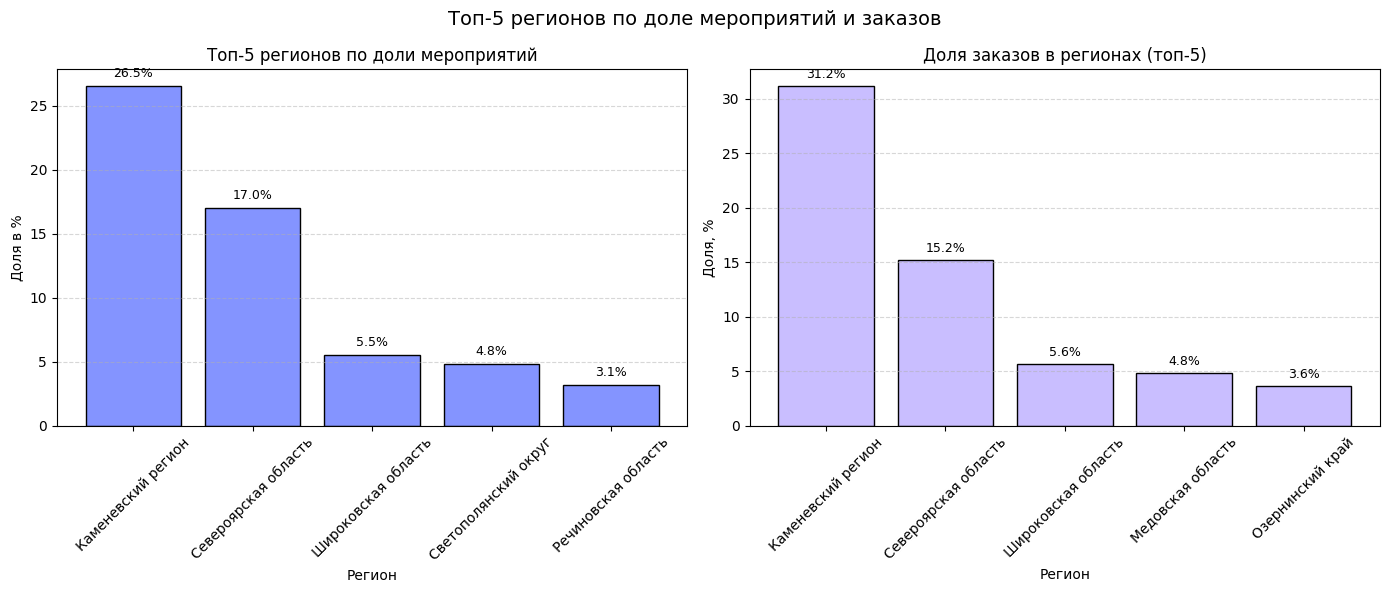

In [79]:
# Создаём фигуру и оси
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Топ-5 регионов по доле мероприятий и заказов', fontsize=14)

# Создаём столбчатую диаграмму для топ-5 регионов по количеству мероприятий
ax[0].bar(top5_region_events['region_name'], top5_region_events['events_share'], color='#8494FF', edgecolor='black')
ax[0].set_title('Топ-5 регионов по доли мероприятий')
ax[0].set_ylabel('Доля в %')
ax[0].grid(True, axis='y', linestyle='--', alpha=0.5)
ax[0].set_xlabel('Регион')
# Поворачиваем подписи, если длинные
ax[0].tick_params(axis='x', rotation=45)

# Добавляем значения над столбцами
for i, v in enumerate(top5_region_events['events_share']):
    ax[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# Создаём столбчатую диаграмму для топ-5 регионов по количеству заказов
ax[1].bar(top5_region_orders['region_name'], top5_region_orders['orders_share'], color='#C9BEFF', edgecolor='black')
ax[1].set_title('Доля заказов в регионах (топ-5)')
ax[1].set_ylabel('Доля, %')
ax[1].grid(True, axis='y', linestyle='--', alpha=0.5)
ax[1].set_xlabel('Регион')
ax[1].tick_params(axis='x', rotation=45)

# Добавляем значения над столбцами
for i, v in enumerate(top5_region_orders['orders_share']):
    ax[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Популярные партнёры

Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. 

In [80]:
# Считаем статистику по партнёрам
partner_stats = tickets_clean.groupby('service_name').agg(
    events_count=('event_id', 'nunique'),
    orders_count=('order_id', 'count'),
    ticket_revenue=('revenue_rub', 'sum')
).reset_index().copy()

Посчитаем доли уникальных мероприятий, обработанных заказов и суммарную выручку от их общего числа в зависимости от партнёра.

In [81]:
# Считаем общее количество событий, заказов и общую выручку
total_events = tickets_clean['event_id'].nunique()
total_orders = len(tickets_clean)
total_revenue = tickets_clean['revenue_rub'].sum()

# Считаем доли
partner_stats['events_share'] = (partner_stats['events_count'] / total_events * 100).round(2)
partner_stats['orders_share'] = (partner_stats['orders_count'] / total_orders * 100).round(2)
partner_stats['revenue_share'] = (partner_stats['ticket_revenue'] / total_revenue * 100).round(2)

Отсортируем полученные результаты.

In [82]:
# Сортируем билетных партнёров по количеству мероприятий
top5_partner_events = partner_stats.sort_values('events_count', ascending=False).reset_index(drop=True).head(5)

# Сортируем билетных партнёров по количеству заказов
top5_partner_orders = partner_stats.sort_values('orders_count', ascending=False).reset_index(drop=True).head(5)

# Сортируем билетных партнёров по суммарной выручке
top5_partner_revenue = partner_stats.sort_values('ticket_revenue', ascending=False).reset_index(drop=True).head(5)

Посмотрим на полученные результаты.

In [83]:
print('Топ-5 билетных партнёров по количеству мероприятий:')
top5_partner_events.head(5)

Топ-5 билетных партнёров по количеству мероприятий:


,service_name,events_count,orders_count,ticket_revenue,events_share,orders_share,revenue_share
0,Лови билет!,4867,40800,1.667385e+07,21.77,14.18,11.17
1,Билеты без проблем,4247,62855,2.432207e+07,18.99,21.84,16.30
2,Билеты в руки,3530,40277,1.319345e+07,15.79,14.00,8.84
3,Облачко,2335,26402,1.858861e+07,10.44,9.18,12.45
4,Лучшие билеты,1762,17741,2.724061e+06,7.88,6.17,1.83


In [84]:
print('Топ-5 билетных партнёров по количеству заказов:')
top5_partner_orders.head(5)

Топ-5 билетных партнёров по количеству заказов:


,service_name,events_count,orders_count,ticket_revenue,events_share,orders_share,revenue_share
0,Билеты без проблем,4247,62855,2.432207e+07,18.99,21.84,16.30
1,Лови билет!,4867,40800,1.667385e+07,21.77,14.18,11.17
2,Билеты в руки,3530,40277,1.319345e+07,15.79,14.00,8.84
3,Мой билет,1300,34438,2.204190e+07,5.81,11.97,14.77
4,Облачко,2335,26402,1.858861e+07,10.44,9.18,12.45


In [85]:
print('Топ-5 билетных партнёров по суммарной выручке:')
top5_partner_revenue.head(5)

Топ-5 билетных партнёров по суммарной выручке:


,service_name,events_count,orders_count,ticket_revenue,events_share,orders_share,revenue_share
0,Билеты без проблем,4247,62855,2.432207e+07,18.99,21.84,16.30
1,Мой билет,1300,34438,2.204190e+07,5.81,11.97,14.77
2,Облачко,2335,26402,1.858861e+07,10.44,9.18,12.45
3,Лови билет!,4867,40800,1.667385e+07,21.77,14.18,11.17
4,Весь в билетах,855,16424,1.653235e+07,3.82,5.71,11.08


**Промежуточный вывод:**
- **Популярность регионов:**
    - Рынок билетных продаж высококонцентрирован географически, поскольку топ-5 регионов имеют более половины мероприятий и количества продаж билетов от общего количества регионов. 
    -  Каменевский регион - это самый крупный регион по всем показателям, на него приходится 26.54% (5 935 мероприятий) всех уникальных мероприятий и 31.16% всех заказов (89 660 заказов). Это самый крупный регион по всем показателям.
    -  Североярская область занимает второе место, на нее приходится 17% мероприятий (3 800 мероприятий), 15.20% заказов (43 738 заказов).
    -  В топ-5 регионов по количеству мероприятий вошли:
        - Каменевский регион: 5 935 мероприятий, 26.54%
        - Североярская область: 3 800 мероприятий, 17%
        - Широковская область: 1 232 мероприятий, 5.51%
        - Светополянский округ: 1 075 мероприятий, 4.81%
        - Светополянский округ: 702 мероприятий, 3.14%
    -  В топ-5 регионов по количеству заказов вошли:
        - Каменевский регион: 89 660 заказов, 31.16%
        - Североярская область: 43 738 заказов, 15.20%
        - Широковская область: 16 169 заказов, 5.62%
        - Медовская область: 13 890 заказов, 4.83%
        - Озернинский край:	10 405 заказов, 3.62%
- **Популярность партнёров:**
    - Рынок билетных продаж высококонцентрирован по билетным партнёрам (несколько партнёров обслуживают львиную долю заказов и выручки).
    - 'Билеты без проблем' лидирует по числу заказов (21,84% от всех заказов) и по выручке (16,30% от общей выручки).
    - 'Лови билет!' лидирует по числу уникальных мероприятий (21,77% от всех мероприятий), но по заказам уступает (14,18%).
    - 'Мой билет' и 'Облачко' также входят в топ‑3 по выручке, где 'Мой билет' имеет 14,8% и 'Облачко' 12,5% от всей выручки.

**Вывод:** ключевые решения по маркетингу, развитию и инвестициям должны быть ориентированы на лидеров, однако для снижения рисков и расширения аудитории возможно развитие менее активных регионов и поддержка более мелких партнёров.

### <a id='conslusion3'>Вывод по исследовательскому анализу данных</a>

[Вернуться к содержанию](#content)

**На основе проведенного исследовательского анализа данных можно сделать следующие выводы:**
- **Сезонность и распределение заказов:**
    - Количество заказов с июня по октябрь 2024 года увеличилось на 190,58% (с 34 164 до 99 273).
    - Осенью наблюдается перераспределение спроса: доля театра выросла с 20,1% до 25.34%, спорта - с 2.52% до 11.19%, что связано с началом театрального и спортивного сезонов. Доля концертов снизилась с 42.6% до 37.2%, но они остаются самой популярной категорией.
- **Устройства и возрастной рейтинг:**
    - Мобильные устройства остаются основным каналом продаж (80.64% летом и 79.65% осенью), небольшое снижение на 0.9 процентного пункта может быть связано с ростом использования десктопов (19.35% летом и 20.34% осенью).
    - Осенью выросла доля мероприятий без возрастных ограничений (0+) с 17.96% летом до 23.61% осенью, а доля мероприятий с возрастным ограничением 18+ сократилась с 14.96% до 10.43%, равно как и доля мероприятий 16+ сокращение доли с 28.33% летом до 26.22% осенью, что может указывать на смещение афиши в сторону семейных и подростковых событий.
- **Динамика средней выручки с заказа одного билета:**
    - Концерты - лидируют по средней цене за билет как летом (304.78 руб.), так и осенью (268.36 руб.), однако наблюдается снижение стоимости на билет на –12%. 
    - Средняя выручка с одного билета осенью снизилась в большинстве категорий (театр –17.8%, концерты –12%, ёлки –15.4%), за исключением стендапа (+5.8%) и выставок (+4.8%). Возможно, это связано с ростом конкуренции и появлением осенних акций.
- **Динамика осенней активность пользователей (сентябрь-октябрь 2024г.):**
    - Заказы и DAU растут к концу октября. Аномальные всплески (3 сентября, 1 октября) сопровождались резким снижением средней цены, что, вероятно, вызвано специальными акциями.
    - Недельная цикличность: максимум заказов и DAU приходится на вторник и пятницу, минимум - на воскресенье и понедельник. В будни серденее число заказов выше, чем в выходные (2 907 против 2 396 заказов), что может быть связано с корпоративными мероприятиями и планированием досуга. Также в бидни выше DAU в сравнении с выходными (937 DAU в будни против 888 DAU в выходные).
- **Популярные регионы и партнёры:**
    - Каменевский регион является лидером по всем показателям (26.54% всех мероприятий и 31.16% заказов). Вместе с Североярской областью (17% всех мероприятий и 15.2% заказов) и Широковской областью (5.51% всех мероприятий и 5.62% заказов) они формируют более половины рынка.
    - Среди партнёров 'Билеты без проблем' лидирует по числу заказов (21.84%) и выручке (16.3%). 'Лови билет!' лидирует по количеству уникальных мероприятий (21.77%). Топ‑3 партнёра обслуживают около 50% заказов.

**Рекомендации:**
- Усилить маркетинговую активность в будние дни, особенно во вторник и пятницу, а также в регионах с высокой концентрацией (Каменевский регион, Североярская область).
- Использовать пиковые дни (3 сентября, 1 октября) как пример успешных акций для стимулирования продаж.
- Сбалансировать ассортимент, учитывая рост спроса на театр и спорт осенью, а также увеличить долю мероприятий для семейной аудитории (0+).
- Для снижения зависимости от ключевых партнёров развивать сотрудничество с менее популярными билетными партнёрами, особенно в регионах с растущим спросом.

## <a id='part4'>Часть 4. Статистический анализ данных</a>

### <a id='part4.1'>4.1. Гипотеза: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.</a>

[Вернуться к содержанию](#content)

**Особенности А/В теста:**
- **Гипотеза:** Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
- **Формулировка нулевой и альтернативной гипотез:**
    - **Нулевая гипотеза (H₀):** среднее количество заказов на одного пользователя у мобильной группы не больше, чем у стационарной группы.
    - **Альтернативная гипотеза (H₁):** среднее количество заказов на одного пользователя у мобильной группы больше, чем у стационарной группы. 
- **Целевая метрика:** в данному случае целевой метрикой будет являться среднее количество заказов на одного пользователя (за осенний период).

По условию технического задания для проведения статистического анализа нужно использовать данные только за осенний период.

In [86]:
# Выводим основную информацию датасета autumn_data
autumn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168623 entries, 2 to 287736
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                168623 non-null  int32         
 1   user_id                 168623 non-null  object        
 2   created_dt_msk          168623 non-null  datetime64[ns]
 3   created_ts_msk          168623 non-null  datetime64[ns]
 4   event_id                168623 non-null  int32         
 5   cinema_circuit          168623 non-null  object        
 6   age_limit               168623 non-null  int8          
 7   currency_code           168623 non-null  object        
 8   device_type_canonical   168623 non-null  object        
 9   revenue                 168623 non-null  float64       
 10  service_name            168623 non-null  object        
 11  tickets_count           168623 non-null  int8          
 12  total                   168623 non-

Формируем две выборки для мобильных устройств и для десктопа.

In [87]:
# Выводим количество уникальных пользователей для мобильных устройств и для десктопа
mobile_users = autumn_data[autumn_data['device_type_canonical'] == 'mobile']['user_id'].unique().copy()
desktop_users = autumn_data[autumn_data['device_type_canonical'] == 'desktop']['user_id'].unique().copy()

print(f'Количество пользователей мобильных устройств: {len(mobile_users)}')
print(f'Количество пользователей десктопа: {len(desktop_users)}')

Количество пользователей мобильных устройств: 14192
Количество пользователей десктопа: 4868


Проверим отсутствие пересечений с конкурирующим тестом.

In [88]:
# Проверим пересечения с конкурирующим тестом.
intersection_users = set(mobile_users) & set(desktop_users)

# Выводим результат
print(f'Количество пользователей, пересекающихся с другими тестами: {len(intersection_users)}')

Количество пользователей, пересекающихся с другими тестами: 3249


Обнаруженное пересечение в 3 249 пользователей означает, что эти пользователи одновременно находятся в двух разных выборках: mobile_users и desktop_users.

Узнаем процент пользователей, которые могут совершать покупки билетов и через мобильные устройства и через десктоп, т.е. пользователей, которые находятся в двух разных выборках: mobile_users и desktop_users. 

In [89]:
# Считаем общее количество пользователей
all_users = set(mobile_users) | set(desktop_users)

# Считаем процент пользователей, которые одновременно используют мобильные устройства и десктоп
intersection_percent = len(intersection_users) / len(all_users) * 100

print(f"Всего уникальных пользователей: {len(all_users)}")
print(f"Процент пользователей, использующих оба устройства: {intersection_percent:.2f}%")

Всего уникальных пользователей: 15811
Процент пользователей, использующих оба устройства: 20.55%


Из результата видно, что не следует из данных исключать пересечение пользователей, использующих оба типа устройств по следующим причинам: 
- Один пользователь может заказывать билеты и с мобильного устройства, и с десктопа. Его поведение в каждом случае - это отдельные наблюдения, которые должны учитываться в соответствующих группах.
- Исключение таких пользователей приводит к сильной потере данных, поскольку процент пользователей, использующих оба устройства составляет 20.55%, их исключение может исказить результаты статистического анализа.

Группируем по user_id и device_type_canonical и считаем число заказов.

In [90]:
# Считаем число заказов
autumn_orders_count = autumn_data.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
autumn_orders_count .columns = ['user_id', 'device', 'orders_count']

autumn_orders_count.head()

,user_id,device,orders_count
0,0005ca5e93f2cf4,mobile,1
1,000898990054619,mobile,2
2,000a55a418c128c,mobile,2
3,001e7037d013f0f,mobile,2
4,00245c702bc343e,mobile,2


Разделим заказы пользователей на группы в зависимости от типа устройства.

In [91]:
# Отделяем пользователей мобильных устройств и пользователей десктопа
autumn_mobile_orders = autumn_orders_count[autumn_orders_count ['device'] == 'mobile']['orders_count']
autumn_desktop_orders = autumn_orders_count[autumn_orders_count ['device'] == 'desktop']['orders_count']

# Выводим полученные размеры групп
print(f'Количество заказов у пользователей мобильных устройств: {len(autumn_mobile_orders)}')
print(f'Количество заказов у пользователей десктопа: {len(autumn_desktop_orders)}')

Количество заказов у пользователей мобильных устройств: 14192
Количество заказов у пользователей десктопа: 4868


Посмотрим основные статистические показатели датасетов autumn_mobile_orders и autumn_desktop_orders

In [92]:
# Выводим основные статистические показатели у датасета autumn_mobile_orders
autumn_mobile_orders.describe()

count    14192.000000
mean         9.464487
std         68.045658
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       4333.000000
Name: orders_count, dtype: float64

In [93]:
# Выводим основные статистические показатели у датасета autumn_mobile_orders
autumn_desktop_orders.describe()

count    4868.000000
mean        7.046631
std        35.987323
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1502.000000
Name: orders_count, dtype: float64

В данном случае для проверки гипотезы следует применять t-тест Уэлча, поскольку у нас размер выборок разный и различаются дисперсии.

In [94]:
# Пишем t-тест Уэлча
stat, p_value = ttest_ind(
    autumn_mobile_orders,
    autumn_desktop_orders,
    alternative='greater',
    equal_var=False
)

print(f't-statistic: {stat:.4f}') 
print(f'p-value: {p_value:.6f}')

alpha = 0.05 # уровень значимости

# Интерпретация
if p_value < alpha:
    print('Нулевая гипотеза не находит подтверждения! Мобильные пользователи совершают в среднем больше заказов, чем десктопные.')
else:
    print('Нулевая гипотеза находит подтверждение!')

t-statistic: 3.1417
p-value: 0.000841
Нулевая гипотеза не находит подтверждения! Мобильные пользователи совершают в среднем больше заказов, чем десктопные.


**Промежуточный вывод:**
- Выделены пользователи мобильных и десктопных устройств. Как результат, получены следующие группы: 14 192 пользователей с мобильными устройствами и 4 868 пользователей десктопа.
- Для каждого пользователя подсчитано среднее количество заказов:
    - 9.46 заказа для пользователей мобильных устройств.
    - 7.04 заказа для пользователей десктопа.
- Согласно статистике в выборках достаточно высокое стандартное отклонение:
    - 68.04 у заказов с мобильных устройств
    - 35.98 у заказов с десктопа
- Выполнен t-тест Уэлча, учитывающий неравенство дисперсий и разный размер выборок.
- Результат A/B теста Уэлча: t-statistic = 3.1417, p‑value < 0.05. Нулевая гипотеза отвергается.

**Вывод:** статистически значимо подтверждено, что в осенний период пользователи мобильных устройств совершают в среднем больше заказов, чем пользователи стационарных устройств.

### <a id='part4.2'>4.2. Гипотеза: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.</a>

[Вернуться к содержанию](#content)

**Особенности А/В теста:**
- **Гипотеза:** Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
    - **Нулевая гипотеза (H₀):** среднее время между заказами у пользователей мобильных устройств не выше, чем у пользователей стационарных устройств.
    - **Альтернативная гипотеза (H₁):** среднее время между заказами у пользователей мобильных устройств выше, чем у пользователей стационарных устройств.
- **Целевая метрика:** в данному случае целевой метрикой будет являться среднее время между заказами (в днях) для пользователей, измеряемое по всем интервалам между последовательными заказами (days_since_prev) в осенний период.

Отбираем интервалы заказов, в которых отсутствуют пустые значения в столбце days_since_prev

In [95]:
# Отбираем интервалы заказов
autumn_order_intervals = autumn_data[autumn_data['days_since_prev'].notna()].copy()

Разделим данные в зависимости от типа устройства.

In [96]:
# Разделяем данные в зависимости от типа устройства
autumn_mobile_intervals = autumn_order_intervals[autumn_order_intervals['device_type_canonical'] == 'mobile'].copy()
autumn_desktop_intervals = autumn_order_intervals[autumn_order_intervals['device_type_canonical'] == 'desktop'].copy()

Вычислим среднее время между заказами пользователей в зависимости от типа устройства.

In [97]:
# Вычисляем среднее время между заказами для каждого пользователя
autumn_mobile_intervals_avg = autumn_mobile_intervals.groupby('user_id')['days_since_prev'].mean()
autumn_desktop_intervals_avg = autumn_desktop_intervals.groupby('user_id')['days_since_prev'].mean()

Посмотрим основные статистические показатели датасетов autumn_mobile_intervals_avg и autumn_desktop_intervals_avg.

In [98]:
# Выводим основные статистические показатели датасета autumn_mobile_intervals_avg
autumn_mobile_intervals_avg.describe()

count      10195.0
mean     20.626369
std      27.361338
min            0.0
25%       2.051316
50%            9.5
75%           28.0
max          148.0
Name: days_since_prev, dtype: Float64

In [99]:
# Выводим основные статистические показатели датасета autumn_desktop_intervals_avg
autumn_desktop_intervals_avg.describe()

count       4034.0
mean      14.85833
std      24.201024
min            0.0
25%            1.0
50%            4.5
75%           17.0
max          146.0
Name: days_since_prev, dtype: Float64

В данном случае для проверки гипотезы следует применять t-тест Уэлча, поскольку у нас размер выборок разный и различаются дисперсии.

In [100]:
# Преобразуем в обычные float, чтобы избежать проблем с nullable типами
autumn_mobile_intervals_float = autumn_mobile_intervals_avg.astype(float)
autumn_desktop_intervals_float = autumn_desktop_intervals_avg.astype(float)

# Пишем t-тест Уэлча
stat, p_value = ttest_ind(
    autumn_mobile_intervals_float, 
    autumn_desktop_intervals_float, 
    alternative='greater',
    equal_var=False
)

print(f't-statistic: {stat:.4f}') 
print(f'p-value: {p_value:.6f}')

alpha = 0.05 # уровень значимости

# Интерпретация
if p_value < alpha:
    print('Нулевая гипотеза не находит подтверждения! Время между заказами у мобильных пользователей статистически значимо выше.')
else:
    print('Нулевая гипотеза не отвергается. Различие не статистически значимо.')

t-statistic: 12.3362
p-value: 0.000000
Нулевая гипотеза не находит подтверждения! Время между заказами у мобильных пользователей статистически значимо выше.


**Промежуточный вывод:**
- В ходе проведения статистического теста для проверки гипотезы  о среднем времени между заказами пользователей в завимисмости от типа устройства были проанализировались интервалы с количеством дней с предыдущей покупки для каждого пользователя (days_since_prev).
- Выделены пользователи мобильных и десктопных устройств. Как результат, получены следующие группы: 10 195 пользователей с мобильными устройствами и 4 034 пользователей десктопа.
- Для каждого пользователя подсчитано медиана времени между заказами:
    - 9.5 дней между заказами для пользователей мобильных устройств.
    - 4.5 дней между заказами для пользователей десктопа.
- Для каждого пользователя подсчитано среднее время между заказами:
    - 20.62 дней между заказами для пользователей мобильных устройств.
    - 14.85 дней между заказами для пользователей десктопа.
- Согласно статистике в выборках достаточно высокое стандартное отклонение:
    - 27.36 у пользователей мобильных устройств.
    - 24.20 у пользователей десктопа.
- Выполнен t-тест Уэлча, учитывающий неравенство дисперсий и разный размер выборок.
- Результат проведенного A/B теста Уэлча: t-statistic = 12.3362, p‑value < 0.005.

**Вывод:** нулевая гипотеза отвергается. Время между заказами у пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

### <a id='conslusion4'>Вывод по статистическому анализу данных</a>

[Вернуться к содержанию](#content)

**В ходе статистического анализа были проверены две гипотезы, предполагающие более высокую активность пользователей мобильных устройств по сравнению с пользователями стационарных (десктопных) устройств в осенний период 2024 года:**
- **Гипотеза № 1: 'Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств':**
    - **Метрика:** среднее количество заказов на одного пользователя (за осенний период).
    - **Подготовка данных:**
        - Были сформированы две группы пользователей в зависимости от типа устройства:
            - Пользователи мобильных устройств: 14 192
            - Пользователи десктопа: 4 868.
    - **Статистический тест:**
        - Для проверки гипотезы был применен односторонний t-тест Уэлча (alternative='greater'), выбран из-за разного размера выборок и наличия выбросов.
        - Результатом статистического теста стало отвергнутая нулевая гипотеза: t-statistic = 3.1417, p‑value < 0.05.
    - **Вывод:** статистически значимо подтверждено, что в осенний период мобильные пользователи совершают в среднем больше заказов, чем десктопные.
- **Гипотеза № 2: 'Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств':**
    - **Метрика:** среднее время между заказами (в днях) для пользователей, измеряемое по всем интервалам между последовательными заказами (days_since_prev) в осенний период.
    - **Подготовка данных:**
        - Были проанализированы интервалы между последовательными заказами (days_since_prev), в которых отсутствуют пустые значения.
        - Были сформированы две группы пользователей в зависимости от типа устройства:
            - Пользователи мобильных устройств: 10 195 
            - Пользователи десктопа: 4 034.
    - **Статистический тест:**
        - Для проверки гипотезы был применен односторонний t-тест Уэлча (alternative='greater'), выбран из-за разного размера выборок и наличия выбросов.
        - Результатом статистического теста стало отвергнутая нулевая гипотеза: t-statistic = 12.3362, p‑value < 0.005.
    - **Вывод:** статистически значимо подтверждено, что среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
- **Интерпретация полученных результатов при проверке гипотез:**
    - Пользователи мобильных устройств имеют более высокую активность (чаще покупают билеты) и при этом имеют большие паузы между покупками.

## <a id='part5'>Общий вывод и рекомендации</a>

[Вернуться к содержанию](#content)

**Главные выводы и рекомендации по проведенным исследованиям:**
- **Предобработка данных и подготовка их к исследованию.**
    - Исходные данные включали три датасета: заказы (orders), мероприятия (events) и курсы тенге к рублю (tenge). После объединения,фильтрации выбросов по 99-му процентилю, устранения неявных дубликатов и оптимизации типов данных итоговый датафрейм tickets_clean составил 287 739 заказов. Пропуски остались только в допустимом столбце days_since_prev.
    - Количественная оценка очистки данных:
        - Исходный размер датасета tickets был записан в переменную temp: 290 849 записей (количество данных после объединения датасетов orders и events, но до предобработки данных: удаления пропусков, фильтрации, удаления дубликатов).
        - Во время предобработки было удалено 238 пропусков, отфильтровано 2 829 записей, удалено 43 неявных дубликата записей.
        - После всех шагов очистки размер tickets_clean составил 287 739 записей.
        - В ходе предобработки было отфильтровано и удалено 3 110 записей, что соответствует 1,07% от исходного объёма.
    - В датасет tickets_clean были преобразованы следующие типы данных:
        - Столбцы с датой и временем (created_dt_msk, created_ts_msk) приведены к типу datetime64.
        - Столбцы, содержащие целочисленные значения, а именно: order_id, event_id, age_limit, tickets_count, city_id, venue_id приведены к типу данных integer с понижением разрядности.
    - В датасет tickets_clean были успешно добавлены четыре новых столбца, необходимые для дальнейшего исследовательского анализа:
        - revenue_rub - выручка с заказа, приведённая к единой валюте - российскому рублю.
        - one_ticket_revenue_rub - выручка с продажи одного билета на мероприятие.
        - month - месяц оформления заказа (целое число от 1 до 12).
        - season - сезон, соответствующий месяцу заказа.
- **Основные результаты исследовательского анализа.**
    - Сезонность и распределение заказов:
        - Количество заказов с июня по октябрь 2024 года увеличилось на 190,58% (с 34 164 до 99 273).
        - Осенью наблюдается перераспределение спроса: доля театра выросла с 20,1% до 25.34%, спорта - с 2.52% до 11.19%, что связано с началом театрального и спортивного сезонов. Доля концертов снизилась с 42.6% до 37.2%, но они остаются самой популярной категорией.
    - Устройства и возрастной рейтинг:
        - Мобильные устройства остаются основным каналом продаж (80.64% летом и 79.65% осенью), небольшое снижение на 0.9 процентного пункта может быть связано с ростом использования десктопов (19.35% летом и 20.34% осенью).
        - Осенью выросла доля мероприятий без возрастных ограничений (0+) с 17.96% летом до 23.61% осенью, а доля мероприятий с возрастным ограничением 18+ сократилась с 14.96% до 10.43%, равно как и доля мероприятий 16+ сокращение доли с 28.33% летом до 26.22% осенью, что может указывать на смещение афиши в сторону семейных и подростковых событий.
    - Динамика средней выручки с заказа одного билета:
        - Концерты - лидируют по средней цене за билет как летом (304.78 руб.), так и осенью (268.36 руб.), однако наблюдается снижение стоимости на билет на -12%.
        - Средняя выручка с одного билета осенью снизилась в большинстве категорий (театр -17.8%, концерты -12%, ёлки -15.4%), за исключением стендапа (+5.8%) и выставок (+4.8%). Возможно, это связано с ростом конкуренции и появлением осенних акций.
    - Динамика осенней активность пользователей (сентябрь-октябрь 2024г.):
        - Заказы и DAU растут к концу октября. Аномальные всплески (3 сентября, 1 октября) сопровождались резким снижением средней цены, что, вероятно, вызвано специальными акциями.
        - Недельная цикличность: максимум заказов и DAU приходится на вторник и пятницу, минимум - на воскресенье и понедельник. В будни серденее число заказов выше, чем в выходные (2 907 против 2 396 заказов), что может быть связано с корпоративными мероприятиями и планированием досуга. Также в бидни выше DAU в сравнении с выходными (937 DAU в будни против 888 DAU в выходные).
    - Популярные регионы и партнёры:
        - Каменевский регион является лидером по всем показателям (26.54% всех мероприятий и 31.16% заказов). Вместе с Североярской областью (17% всех мероприятий и 15.2% заказов) и Широковской областью (5.51% всех мероприятий и 5.62% заказов) они формируют более половины рынка.
        - Среди партнёров 'Билеты без проблем' лидирует по числу заказов (21.84%) и выручке (16.3%). 'Лови билет!' лидирует по количеству уникальных мероприятий (21.77%). Топ‑3 партнёра обслуживают около 50% заказов.
- **Результаты статистического анализа данных.**
    - Гипотеза № 1: 'Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств' подтвердилась:
        - Результатом статистического теста стала отвергнутая нулевая гипотеза: t-statistic = 3.1417, p‑value < 0.05.
        - С помощью одностороннего теста Уэлча (alternative='greater') статистически значимо подтверждено, что в осенний период мобильные пользователи совершают в среднем больше заказов, чем десктопные.
    - Гипотеза № 2: 'Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств' подтвердилась:
        - Результатом статистического теста стала отвергнутая нулевая гипотеза: t-statistic = 12.3362, p‑value < 0.005.
        - С помощью одностороннего теста Уэлча (alternative='greater') статистически значимо подтверждено, что среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
- **Рекомендации.**
    - Усилить маркетинговую активность в будние дни, особенно во вторник и пятницу, а также в регионах с высокой концентрацией (Каменевский регион, Североярская область).
    - Использовать пиковые дни (3 сентября, 1 октября) как пример успешных акций для стимулирования продаж.
    - Сбалансировать ассортимент, учитывая рост спроса на театр и спорт осенью, а также увеличить долю мероприятий для семейной аудитории (0+).
    - Для снижения зависимости от ключевых партнёров развивать сотрудничество с менее популярными билетными партнёрами, особенно в регионах с растущим спросом.